In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [2]:
collective_PBC = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :active => Bool,

        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64,
        :ve => Float64
    ),

    medium = Dict(
        :mm => Float64
    ),

    agentODE = quote

        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]


        idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        
        # X direction
        if x < xmin
            idx = Int(floor(Int, (x+(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        #     x += (xmax - xmin)
        elseif x > xmax
            idx = Int(floor(Int, (x-(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        #     x -= (xmax - xmin)
        end

        # # Y direction
        if y < ymin
            idy = Int(floor(Int,(y+ymax-ymin)/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        #     y += (ymax - ymin)
        elseif y > ymax
            idy = Int(floor(Int,(y-(ymax-ymin))/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        #     y -= (ymax - ymin)
        end
        
        mmb = max(0, mm[idx,idy])

        F = ε0 + ε1 * methyl + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka)) #Equació del paper per definir activitat del receptor
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = vx  #Change position acording to constant speed afected by forces
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote
        
            xmin, xmax = simBox[1,1], simBox[1,2]
            ymin, ymax = simBox[2,1], simBox[2,2]

            idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
            idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2) 

            v_run = v
            v_tumble = 0.25 

            speed = active ? v_run : v_tumble

            Dr_tumble = 6.2      
            Dr_total = active ? Dr_run : Dr_tumble

            mm[idx,idy] += S

            if active 
                λ = ωFrec*exp(-G)
                P = 1 - exp(-λ * dt)
                
            else
                λ = ωFrec*exp(G)
                P = 1 - exp(-λ * dt)  
                
            end


            if active 
                λrt = ωFrec*exp(-G) 

                P_rt = 1 - exp(-λrt * dt)
                P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                    active = false
                    vx = speed* cos(theta) + ve
                    vy = speed* sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
                else     #Si rate baixa 
                    active = true
                    vx = speed * cos(theta) + ve
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
                end

            else
                λtr = ωFrec*exp(G) 
                P_tr = 1 - exp(-λtr * dt)
                P = rand()

                if P < P_tr
                    active = true
                    vx = speed * cos(theta) + ve
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                else
                    active = false
                    vx = speed* cos(theta) + ve
                    vy = speed* sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                end
            end

            
            xmin, xmax = simBox[1,1], simBox[1,2]
            ymin, ymax = simBox[2,1], simBox[2,2]

            if x < xmin
                x += (xmax - xmin)
            elseif x > xmax
                x -= (xmax - xmin)
            end

            # Y direction
            if y < ymin
                y += (ymax - ymin)
            elseif y > ymax
                y -= (ymax - ymin)
            end


    end,


    mediumODE = quote
        if @mediumInside()
            dt(mm) = DMedium *(@∂2(1, mm)+ @∂2(2, mm)) - delta*mm - ve * @∂(1, mm)
        elseif @mediumBorder(1,-1)
            mm = mm[NMedium[1] - 1, i2_]
        elseif @mediumBorder(1,1)
            mm = mm[1, i2_]
        elseif @mediumBorder(2,1)
            mm = mm[i1_, 1]
        elseif @mediumBorder(2,-1)
            mm = mm[i1_, NMedium[2] - 1]
        end
    end,


    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Heun(),
    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=10)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	xₘ (Float64 medium)
	yₘ (Float64 medium)
	M (Float64 agent)
	d (Float64 agent)
	active (Bool agent)
	v (Float64 agent)
	λ (Float64 agent)
	F (Float64 agent)
	A (Float64 agent)
	methyl (Float64 agent)
	vx (Float64 agent)
	l (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	G (Float64 agent)
	vy (Float64 agent)
	S (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	ve (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)
	mm (Float64 medium)


UPDATE RULES
mediumODE
 if @mediumInside()
    dt__mm = (DMedium * (@∂2(1, mm) + @∂2(2, mm)) - delta * mm) - ve * @∂(1, mm)
elseif @mediumBorder(1, -1)
   

In [6]:
com = Community(
    collective_PBC,
    N=500,
    dt=0.01,
    simBox = [-100.0 100.0; -100.0 100.0],
    NMedium = [200, 200]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

# com.v =  0.33   #Velocitat neutrophil (20 microm/min) 
# com.v = 20.0    #(microm/s)
com.v = 10.0
# com.v = 5.0
# com.v = 2.5
# com.v = 1

# com.DMedium = 20 # 0.5
# com.DMedium = 3.33 # 3
com.DMedium = 1.25 # 8

# com.delta = 0.005  # 0.5
# com.delta = 0.03  # 3
com.delta = 0.08  # 8

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.x = rand(Uniform(com.simBox[1,:]...),com.N)
com.y = rand(Uniform(com.simBox[2,:]...),com.N)
com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K


com.active .= true 

com.S = 0.0025
com.ve = 0


0

In [4]:
outfile = "cluster_n8.jld2"
steps = 25000

loadToPlatform!(com, preallocateAgents=400)
com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    for step in 1:steps
        step!(com)
        if step % 100 == 0
            stepname = @sprintf("step_%06d", step)
            g = JLD2.Group(file, stepname)

            # Agent-level arrays (length = N)
            g["x"] = copy(com.x)
            g["y"] = copy(com.y)
            g["theta"] = copy(com.theta)
            g["mm_grid"] = copy(com.mm)
        end
    end
end

In [7]:
using CairoMakie

# steps_to_plot = [100, 10000, 15000, 20000]
steps_to_plot = [100, 1000, 2000, 4000, 6000, 8000, 10000, 12000, 14000, 16000, 18000, 20000]

dark = colorant"#645986"
dark2 = colorant"#7D84B2"
light = colorant"#F2EEF9"
white = colorant"#FFFFFF"
bac = colorant"#0E1428"
cmap = cgrad([white, dark2])
ns = [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
tms = [4.0]
# tms = [1.0, 2.0, 4.0, 10.0]

for (idx_t, tm) in enumerate(tms)

    for (idx_n, n) in enumerate(ns)
        fig4 = Figure(size=(900*4,600*4))

        jldopen("cluster_v5_tm_$(tm)_n$(n).jld2", "r") do file 
            for (j, step) in enumerate(steps_to_plot)

                x = Vector{Float64}(undef, 1)
                y = Vector{Float64}(undef, 1)

                row = ceil(Int, j / 4)
                col = (j - 1) % 4 + 1
    

                ax = CairoMakie.Axis(fig4[row, col], aspect=1, title="Step $step")

                g = file[@sprintf("step_%06d", step)]
            
                mm_grid = g["mm_grid"]
                mm = reshape(mm_grid, (200,200))

                hm = heatmap!(ax, 
                            range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                            range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                            mm_grid, 
                            colormap=cmap
                            )

                x = g["x"]
                y = g["y"]
                theta = g["theta"]
                l = 3
            
                for i in 1:length(x)
                    scatter!(ax, x[i], y[i], color=bac, markersize=4)
                end

                # Colorbar(fig4[1, 2*j], hm, label="Chemoattractant")

            end
            
        end
        save("Plots/Fixed_source_model/Next/Clusters/steps_tm$(tm)_n$(n).pdf", fig4)

    end
end


In [95]:
save("Plots/Fixed_source_model/Next/cluster_n8.pdf", fig4)

CairoMakie.Screen{PDF}


In [3]:
ns = [0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
tms = [4.0]

for (idx, n) in enumerate(ns)
    for (idx_t, tm) in enumerate(tms)

        com = Community(
            collective_PBC,
            N=500,
            dt=0.01,
            simBox = [-100.0 100.0; -100.0 100.0],
            NMedium = [200, 200]
        )

        m = 1/100
        g = 1/10000
        d = 1

        com.Dr_run = 0.062

        com.v = 5.0
        # com.v = 10.0

        Dc = 10
        delta = 0.01/(((tm)^2)*(5/10)^2)

        com.DMedium = Dc / n
        com.delta = delta * n

        com.ωFrec = 1.3
        com.Ki = 0.0182
        com.Ka = 3.0
        com.Nrec = 6.0
        com.ε0   = 6.0
        com.ε1   = -1.0
        com.ε2   = 80
        com.ε3   = 80

        com.τm = tm

        com.α   = 6.0

        com.K = 2.0 

        com.Ky = 100.0
        com.Kz = 10.0
        com.Z = 5.0
        com.Yy = 0.1

        com.m = 1.        
        com.d = 1.        
        com.l = 3;

        com.x = rand(Uniform(com.simBox[1,:]...),com.N)
        com.y = rand(Uniform(com.simBox[2,:]...),com.N)
        com.theta = rand(Uniform(0,2π),com.N)

        com.methyl .= 0.0
        com.Yp .= com.K


        com.active .= true 

        com.S = 0.0025
        com.ve = 0

        outfile = "cluster_v5_tm_$(tm)_n$(n).jld2"
        steps = 25000

        loadToPlatform!(com, preallocateAgents=400)
        com.mm = zeros(Float64, com.NMedium...)

        jldopen(outfile, "w") do file

            for step in 1:steps
                step!(com)
                if step % 100 == 0
                    stepname = @sprintf("step_%06d", step)
                    g = JLD2.Group(file, stepname)

                    # Agent-level arrays (length = N)
                    g["x"] = copy(com.x)
                    g["y"] = copy(com.y)
                    g["theta"] = copy(com.theta)
                    g["mm_grid"] = copy(com.mm)
                end
            end
        end
    end
end


# Add - remove

In [2]:
collective_PBC_add = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :active => Bool,

        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64,
        :ve => Float64
    ),

    medium = Dict(
        :mm => Float64
    ),

    agentODE = quote

        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]


        idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        
        # X direction
        if x < xmin
            idx = Int(floor(Int, (x+(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        #     x += (xmax - xmin)
        elseif x > xmax
            idx = Int(floor(Int, (x-(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        #     x -= (xmax - xmin)
        end

        # # Y direction
        if y < ymin
            idy = Int(floor(Int,(y+ymax-ymin)/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        #     y += (ymax - ymin)
        elseif y > ymax
            idy = Int(floor(Int,(y-(ymax-ymin))/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        #     y -= (ymax - ymin)
        end
        
        mmb = max(0, mm[idx,idy])

        F = ε0 + ε1 * methyl + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka)) #Equació del paper per definir activitat del receptor
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = vx  #Change position acording to constant speed afected by forces
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote
        
            xmin, xmax = simBox[1,1], simBox[1,2]
            ymin, ymax = simBox[2,1], simBox[2,2]

            idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
            idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2) 

            p_add = 0.005

            if i1_ == 1
                for k in 1:10
                    if rand() < p_add
                        @addAgent(
                            x = xmin + 2,
                            y = rand(Uniform(simBox[2,:]...)),
                            theta = 2 * pi,
                            l = 3
                        )
                    end
                end
            end

            v_run = v
            v_tumble = 0.25 

            speed = active ? v_run : v_tumble

            Dr_tumble = 6.2      
            Dr_total = active ? Dr_run : Dr_tumble

            mm[idx,idy] += S

            if active 
                λ = ωFrec*exp(-G)
                P = 1 - exp(-λ * dt)
                
            else
                λ = ωFrec*exp(G)
                P = 1 - exp(-λ * dt)  
                
            end


            if active 
                λrt = ωFrec*exp(-G) 

                P_rt = 1 - exp(-λrt * dt)
                P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                    active = false
                    vx = speed* cos(theta) + ve
                    vy = speed* sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
                else     #Si rate baixa 
                    active = true
                    vx = speed * cos(theta) + ve
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
                end

            else
                λtr = ωFrec*exp(G) 
                P_tr = 1 - exp(-λtr * dt)
                P = rand()

                if P < P_tr
                    active = true
                    vx = speed * cos(theta) + ve
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                else
                    active = false
                    vx = speed* cos(theta) + ve
                    vy = speed* sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                end
            end

            
            xmin, xmax = simBox[1,1], simBox[1,2]
            ymin, ymax = simBox[2,1], simBox[2,2]

            if x <= xmin
                x = xmin + (xmin - x)
                theta = pi - theta
            elseif x >= xmax
                @removeAgent()
            end
            # Y direction
            if y > ymax
                y = 2*ymax - y
                theta = 2*pi - theta
            elseif y <= ymin
                y = 2*ymin - y 
                theta = 2*pi - theta
            end



    end,


    mediumODE = quote
        if @mediumInside()
            dt(mm) = DMedium *(@∂2(1, mm)+ @∂2(2, mm)) - delta*mm - ve * @∂(1, mm)
        elseif @mediumBorder(1,-1)
            # mm = mm[NMedium[1] - 1, i2_]
            mm = 0
        elseif @mediumBorder(1,1)
            # mm = mm[1, i2_]
            mm = 0
        elseif @mediumBorder(2,1)
            mm = mm[i1_, NMedium[2] - 2]
        elseif @mediumBorder(2,-1)
            mm = mm[i1_, 2]
        end
    end,


    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Heun(),
    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=10)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	xₘ (Float64 medium)
	yₘ (Float64 medium)
	M (Float64 agent)
	d (Float64 agent)
	active (Bool agent)
	v (Float64 agent)
	λ (Float64 agent)
	F (Float64 agent)
	A (Float64 agent)
	methyl (Float64 agent)
	vx (Float64 agent)
	l (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	G (Float64 agent)
	vy (Float64 agent)
	S (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	ve (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)
	mm (Float64 medium)


UPDATE RULES
mediumODE
 if @mediumInside()
    dt__mm = (DMedium * (@∂2(1, mm) + @∂2(2, mm)) - delta * mm) - ve * @∂(1, mm)
elseif @mediumBorder(1, -1)
   

In [11]:
com = Community(
    collective_PBC_add,
    N=250,
    dt=0.01,
    simBox = [-100.0 100.0; -100.0 100.0],
    NMedium = [200, 200]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

# com.v = 20.0    #(microm/s)
com.v = 10.0


# com.DMedium = 20 # 0.5
com.DMedium = 3.33 # 3
# com.DMedium = 1.25 # 8

# com.delta = 0.005  # 0.5
com.delta = 0.03  # 3
# com.delta = 0.08  # 8

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.x = rand(Uniform(com.simBox[1,:]...),com.N)
com.y = rand(Uniform(com.simBox[2,:]...),com.N)
com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K


com.active .= true 

com.S = 0.0025
com.ve = 2


2

In [12]:
outfile = "PBC_add_n3_ve2_v10.jld2"
steps = 25000

loadToPlatform!(com, preallocateAgents=1000)
com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    for step in 1:steps
        step!(com)
        if step % 100 == 0
        stepname = @sprintf("step_%06d", step)
            g = JLD2.Group(file, stepname)

            # Agent-level arrays (length = N)
            g["x"] = copy(com.x)
            g["y"] = copy(com.y)
            g["theta"] = copy(com.theta)
            g["mm_grid"] = copy(com.mm)
        end
    end
end

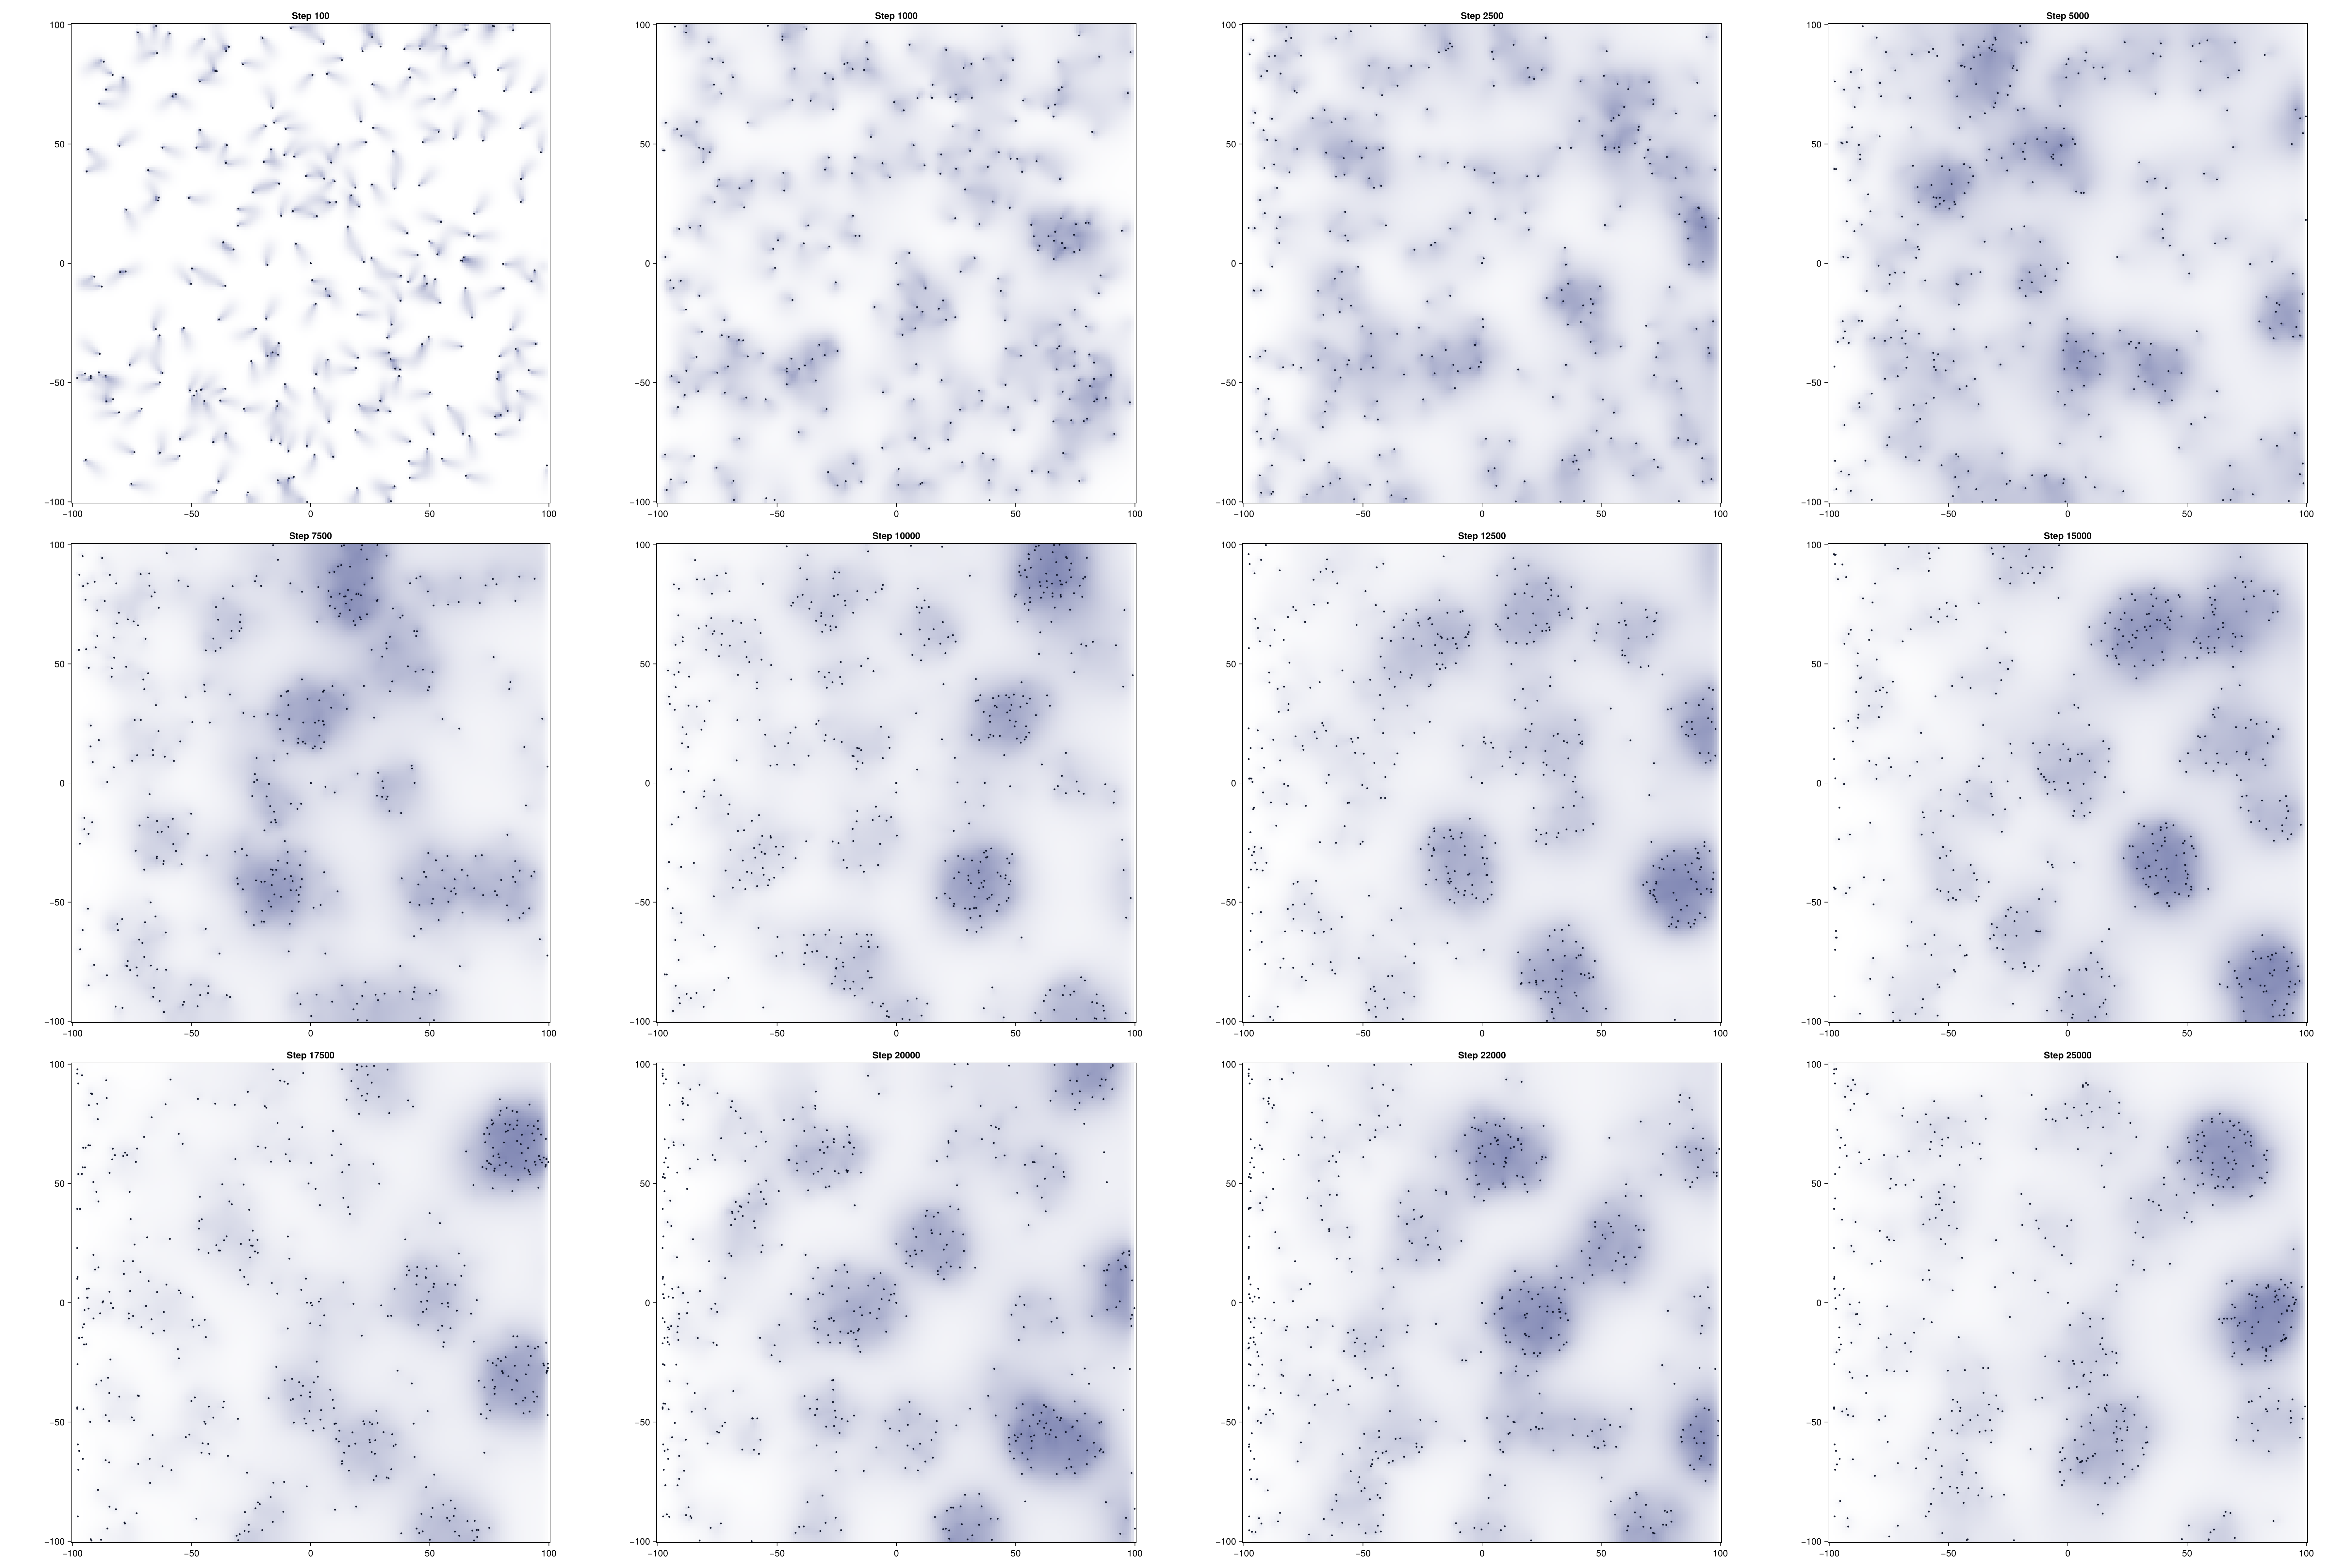

CairoMakie.Screen{IMAGE}


In [13]:
using CairoMakie
fig_2 = Figure(size=(900*4,600*4))

steps_to_plot = [100, 1000, 2500, 5000, 7500, 10000, 12500, 15000, 17500, 20000, 22000, 25000]

dark = colorant"#645986"
dark2 = colorant"#7D84B2"
light = colorant"#F2EEF9"
white = colorant"#FFFFFF"
bac = colorant"#0E1428"
cmap = cgrad([white, dark2])

jldopen("PBC_add_n3_ve2_v10.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        x = Vector{Float64}(undef, 1)
        y = Vector{Float64}(undef, 1)

        row = ceil(Int, j / 4)
        col = (j - 1) % 4 + 1

        ax = Axis(fig_2[row, col], aspect=1, title="Step $step")

        g = file[@sprintf("step_%06d", step)]
    
        mm_grid = g["mm_grid"]
        mm = reshape(mm_grid, (200,200))

        hm = heatmap!(ax, 
                    range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                    range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                    mm_grid, 
                    colormap=cmap
                    )

        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3

        for i in 1:length(x)
            scatter!(ax, x[i], y[i], color=bac, markersize=4)
        end

        # Colorbar(fig4[1, 2*j], hm, label="Chemoattractant")

    end
end

display(fig_2)

In [14]:
save("Plots/Fixed_source_model/Next/PBD_add_n3_ve2_v10.pdf", fig_2)

CairoMakie.Screen{PDF}


# Cluster analysis

## Cluster size

In [4]:
using Images, ImageSegmentation, Statistics

function compute_cluster_sizes(z; threshold=nothing)
    # 1. Choose threshold
    if threshold === nothing
        threshold = mean(z) + 0.5*std(z)
    end

    binary = z .> threshold

    # 2. Label clusters
    labels = label_components(binary)

    n = maximum(labels)
    areas = Float64[]

    for i in 1:n
        a = count(labels .== i)
        if a > 5   # remove tiny noise
            push!(areas, a)
        end
    end

    # 3. Convert to diameters
    diameters = [2 * sqrt(a / π) for a in areas]

    return diameters
end

compute_cluster_sizes (generic function with 1 method)

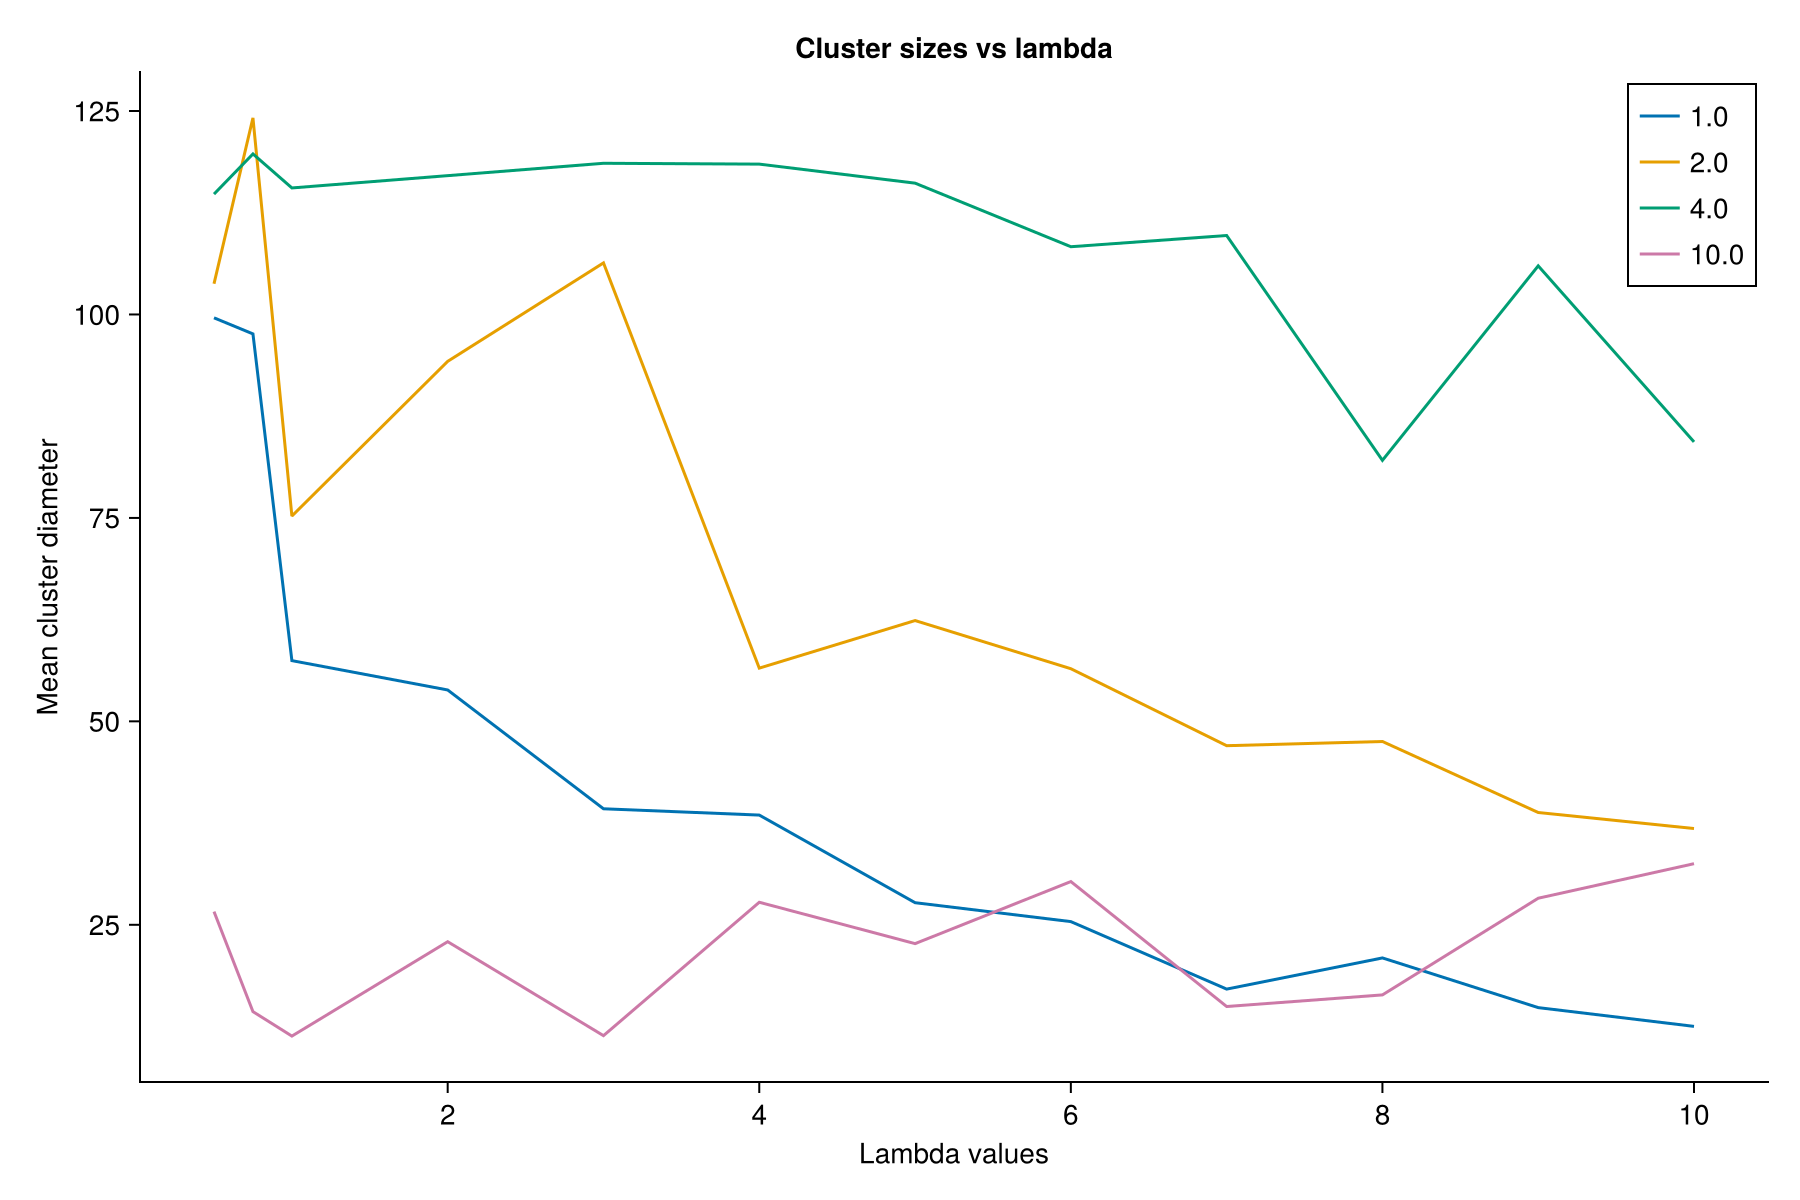

In [17]:
using CairoMakie
# ns = ["05", 0.75, 1.0, 2.0, "3", 4.0, 5.0, 6.0, 7.0, "8", 9.0, 10.0]
ns = [0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
tms = [1.0, 2.0, 4.0, 10.0]

fig = Figure(size=(900,600))
ax = GLMakie.Axis(fig[1,1], title = "Cluster sizes vs lambda", xlabel = "Lambda values", ylabel = "Mean cluster diameter")

for (idx_t, tm) in enumerate(tms)
    mean_clust_size = Float64[]
    for (idx, n) in enumerate(ns)
        filename = "cluster_tm_$(tm)_n$(n).jld2"
        z = jldopen(filename, "r") do file
            g = file[@sprintf("step_%06d", 20000)]
            reshape(g["mm_grid"], (200, 200))
        end

        diams = compute_cluster_sizes(z)

        mean_d = mean(diams)
        push!(mean_clust_size, mean_d)
    end
    lines!(ax, ns, mean_clust_size, label = "$tm")
end

# ax2 = GLMakie.Axis(fig[1,1], yaxisposition = :right)
# scatterlines!(ax, ns1, mean_clust_size)
# lines!(ax2, lambdas_1, escape, color = :purple)
axislegend(ax)
ax.topspinevisible = false
ax.rightspinevisible = false
ax.ygridvisible = false
ax.xgridvisible = false
fig

In [18]:
save("Plots/Fixed_source_model/Next/cluster_size_tm_1.pdf", fig)

CairoMakie.Screen{PDF}


## Account for PBC

In [10]:
using Images, ImageSegmentation

function periodic_labels(binary)

    labels = label_components(binary)

    nx, ny = size(binary)

    changed = true

    while changed
        changed = false

        # ---------------------------------------------
        # LEFT-RIGHT periodic merge
        # ---------------------------------------------
        for i in 1:nx

            l1 = labels[i,1]
            l2 = labels[i,end]

            if l1 > 0 && l2 > 0 && l1 != l2

                labels[labels .== l2] .= l1
                changed = true
            end
        end

        # ---------------------------------------------
        # TOP-BOTTOM periodic merge
        # ---------------------------------------------
        for j in 1:ny

            l1 = labels[1,j]
            l2 = labels[end,j]

            if l1 > 0 && l2 > 0 && l1 != l2

                labels[labels .== l2] .= l1
                changed = true
            end
        end
    end

    return labels
end

periodic_labels (generic function with 1 method)

In [11]:
function compute_cluster_sizes(z; threshold=nothing)

    if threshold === nothing
        threshold = mean(z) + 0.5*std(z)
    end

    binary = z .> threshold

    # periodic labeling
    labels = periodic_labels(binary)

    cluster_ids = unique(labels)
    cluster_ids = cluster_ids[cluster_ids .> 0]

    areas = Float64[]

    for id in cluster_ids

        a = count(labels .== id)

        if a > 5
            push!(areas, a)
        end
    end

    diameters = [2 * sqrt(a / π) for a in areas]

    return diameters
end

compute_cluster_sizes (generic function with 1 method)

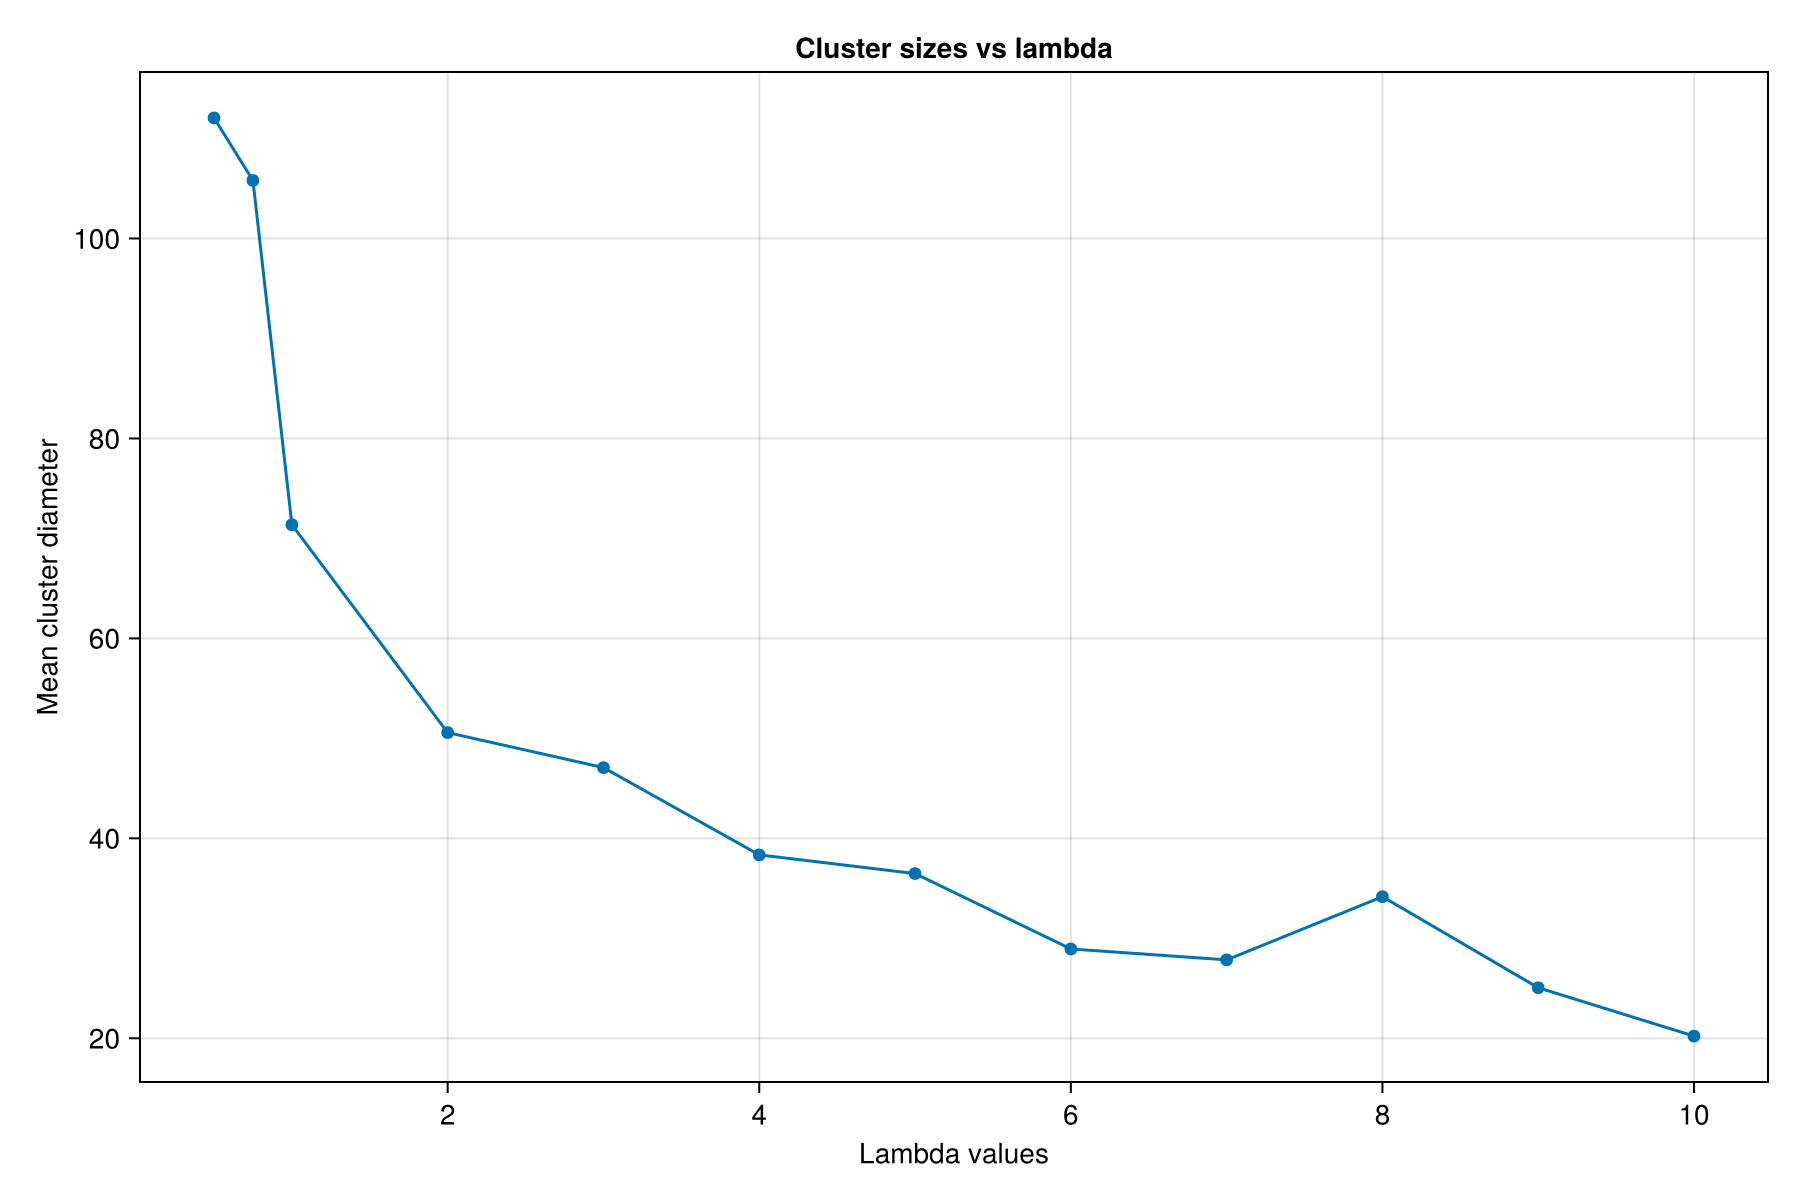

In [16]:
using CairoMakie
mean_clust_size = Float64[]
ns = ["05", 0.75, 1.0, 2.0, "3", 4.0, 5.0, 6.0, 7.0, "8", 9.0, 10.0]
ns1 = [0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

for (idx, n) in enumerate(ns)
    filename = "col_PBC_n$(n)_ve10_v10.jld2"
    z = jldopen(filename, "r") do file
        g = file[@sprintf("step_%06d", 20000)]
        reshape(g["mm_grid"], (200, 200))
    end

    diams = compute_cluster_sizes(z)

    mean_d = mean(diams)
    push!(mean_clust_size, mean_d)
end

fig = Figure(size=(900,600))
ax = GLMakie.Axis(fig[1,1], title = "Cluster sizes vs lambda", xlabel = "Lambda values", ylabel = "Mean cluster diameter")
# ax2 = GLMakie.Axis(fig[1,1], yaxisposition = :right)
scatterlines!(ax, ns1, mean_clust_size)
# lines!(ax2, lambdas_1, escape, color = :purple)

fig

In [17]:
save("Plots/Fixed_source_model/Next/cluster_sizes_1.pdf", fig)

CairoMakie.Screen{PDF}


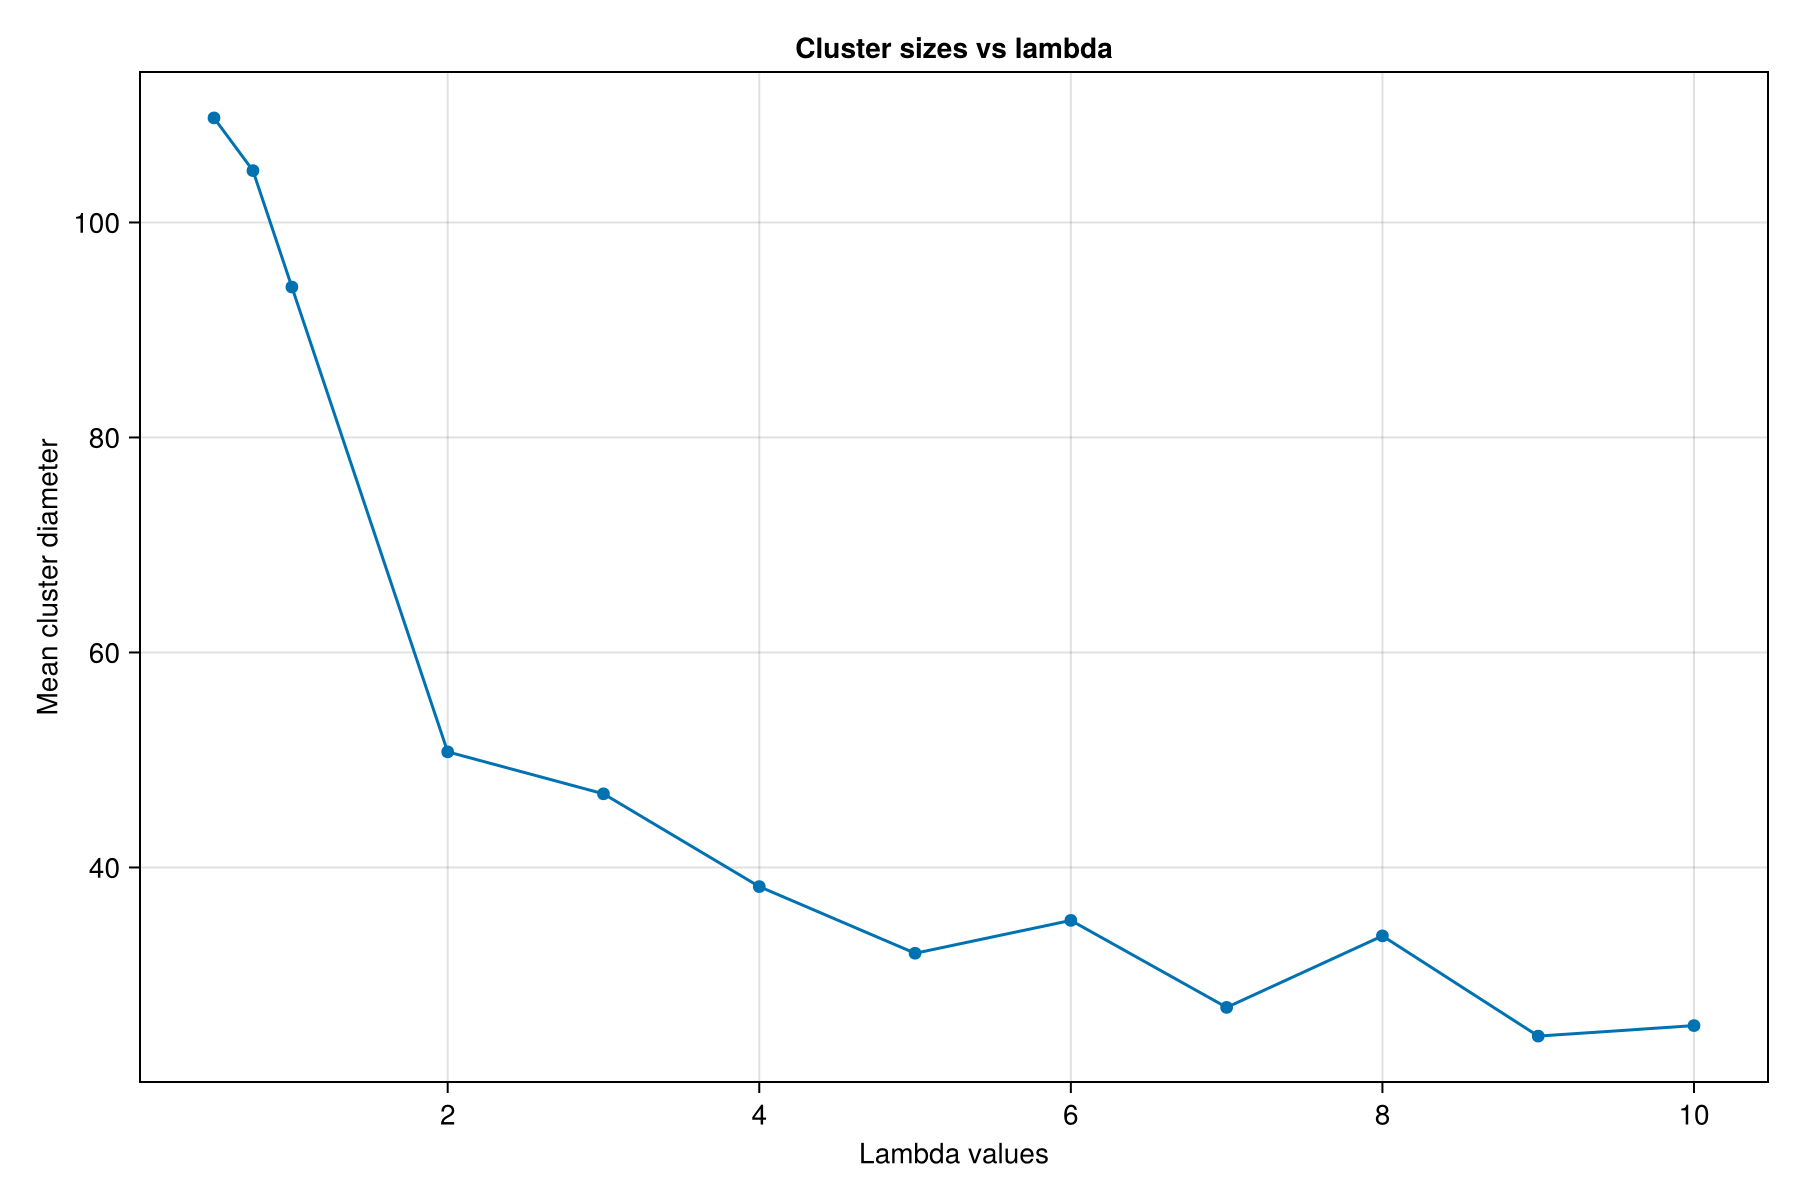

In [18]:
using CairoMakie
using JLD2
using Statistics
using Printf

mean_clust_size = Float64[]

ns = ["05", 0.75, 1.0, 2.0, "3", 4.0, 5.0, 6.0, 7.0, "8", 9.0, 10.0]
ns1 = [0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

# timesteps to average over
timesteps = [20000, 21000, 22000, 23000, 24000, 25000]

for (idx, n) in enumerate(ns)

    filename = "col_PBC_n$(n)_ve10_v10.jld2"

    diam_means = Float64[]

    jldopen(filename, "r") do file

        for step in timesteps

            key = @sprintf("step_%06d", step)

            if haskey(file, key)

                g = file[key]

                z = reshape(g["mm_grid"], (200, 200))

                diams = compute_cluster_sizes(z)

                # avoid errors if no clusters detected
                if !isempty(diams)

                    mean_d = mean(diams)

                    push!(diam_means, mean_d)
                end
            end
        end
    end

    # average across the selected time steps
    mean_over_time = mean(diam_means)

    push!(mean_clust_size, mean_over_time)
end


fig = Figure(size=(900,600))

ax = CairoMakie.Axis(
    fig[1,1],
    title = "Cluster sizes vs lambda",
    xlabel = "Lambda values",
    ylabel = "Mean cluster diameter"
)

scatterlines!(ax, ns1, mean_clust_size)

fig

In [19]:
save("Plots/Fixed_source_model/Next/cluster_sizes_mean_5_steps.pdf", fig)


CairoMakie.Screen{PDF}


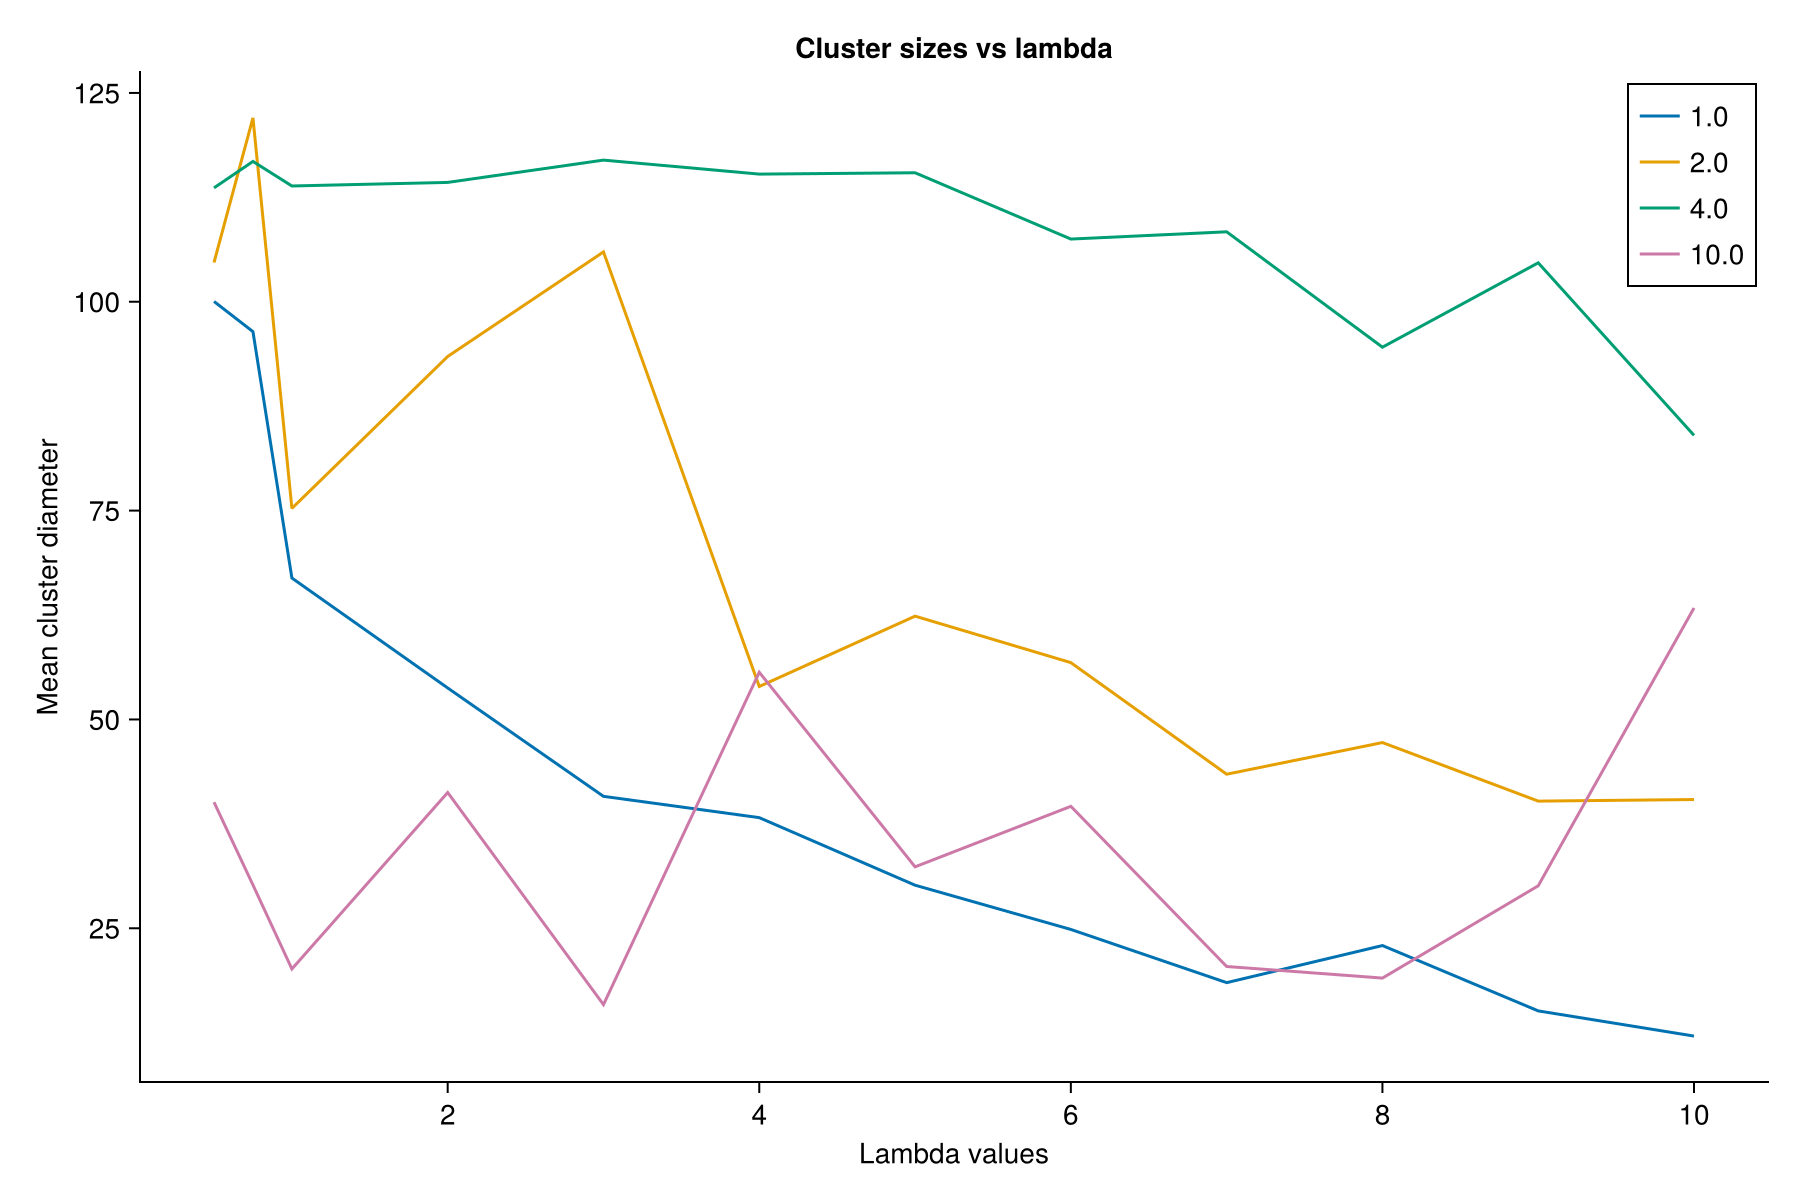

In [19]:
using CairoMakie
# ns = ["05", 0.75, 1.0, 2.0, "3", 4.0, 5.0, 6.0, 7.0, "8", 9.0, 10.0]
ns = [0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
tms = [1.0, 2.0, 4.0, 10.0]

fig = Figure(size=(900,600))

ax = CairoMakie.Axis(
    fig[1,1],
    title = "Cluster sizes vs lambda",
    xlabel = "Lambda values",
    ylabel = "Mean cluster diameter"
)

# timesteps to average over
timesteps = [20000, 21000, 22000, 23000, 24000, 25000]

for (idx_t, tm) in enumerate(tms)
    mean_clust_size = []
    for (idx, n) in enumerate(ns)

        filename = "cluster_tm_$(tm)_n$(n).jld2"


        diam_means = Float64[]

        jldopen(filename, "r") do file

            for step in timesteps

                key = @sprintf("step_%06d", step)

                if haskey(file, key)

                    g = file[key]

                    z = reshape(g["mm_grid"], (200, 200))

                    diams = compute_cluster_sizes(z)

                    # avoid errors if no clusters detected
                    if !isempty(diams)

                        mean_d = mean(diams)

                        push!(diam_means, mean_d)
                    end
                end
            end
        end

        # average across the selected time steps
        mean_over_time = mean(diam_means)

        push!(mean_clust_size, mean_over_time)
    end

    lines!(ax, ns, mean_clust_size, label = "$tm")

end
axislegend(ax)
ax.topspinevisible = false
ax.rightspinevisible = false
ax.ygridvisible = false
ax.xgridvisible = false
fig

In [20]:
save("Plots/Fixed_source_model/Next/cluster_sizes_mean_5.pdf", fig)


CairoMakie.Screen{PDF}


## Time to clsutering

In [53]:
# ---------------------------------------------------------
# Cluster size function
# ---------------------------------------------------------
function compute_cluster_sizes(z; threshold=nothing)

    if threshold === nothing
        threshold = mean(z) + 0.5 * std(z)
    end

    binary = z .> threshold

    labels = periodic_labels(binary)

    n = maximum(labels)

    areas = Float64[]

    for i in 1:n
        a = count(labels .== i)

        if a > 5
            push!(areas, a)
        end
    end

    # equivalent diameters
    diameters = [2 * sqrt(a / π) for a in areas]

    return diameters
end


# ---------------------------------------------------------
# Characteristic cluster size
# ---------------------------------------------------------
function characteristic_size(z)

    diams = compute_cluster_sizes(z)

    isempty(diams) && return 0.0

    # choose ONE:
    return mean(diams)

    # alternatively:
    # return maximum(diams)
end


# ---------------------------------------------------------
# Compute clustering time from one simulation file
# ---------------------------------------------------------
function clustering_time(filename;
                         nsteps=25000,
                         step_interval=100,
                         tol=0.2,
                         window=20)

    times = Int[]
    sizes = Float64[]

    # -----------------------------------------------------
    # Loop through ALL time steps
    # -----------------------------------------------------
    jldopen(filename, "r") do file

        for step in 0:step_interval:nsteps

            key = @sprintf("step_%06d", step)

            if haskey(file, key)

                g = file[key]

                z = reshape(g["mm_grid"], (200, 200))

                s = characteristic_size(z)

                push!(times, step)
                push!(sizes, s)
            end
        end
    end

    # -----------------------------------------------------
    # Final cluster size
    # -----------------------------------------------------
    final_size = sizes[end]

    lower = (1 - tol) * final_size
    upper = (1 + tol) * final_size

    # -----------------------------------------------------
    # Detect stabilization
    # -----------------------------------------------------
    t_cluster = nothing

    for i in 1:(length(sizes) - window + 1)

        stable = all(lower <= sizes[k] <= upper
                     for k in i:(i + window - 1))

        if stable
            t_cluster = times[i]
            break
        end
    end

    return t_cluster, times, sizes
end

clustering_time (generic function with 1 method)

In [54]:
vec_times = []
ns = ["05", 0.75, 1.0, 2.0, "3", 4.0, 5.0, 6.0, 7.0, "8", 9.0, 10.0]

for (idx, n) in enumerate(ns)
    filename = "col_PBC_n$(n)_ve10_v10.jld2"

    t_cluster, times, sizes = clustering_time(filename)
    push!(vec_times, t_cluster)
    println("Clustering time ≈ $t_cluster")
end


Clustering time ≈ 19700
Clustering time ≈ 18200
Clustering time ≈ 21500
Clustering time ≈ 4400
Clustering time ≈ 5400
Clustering time ≈ 8500
Clustering time ≈ 9000
Clustering time ≈ 21600
Clustering time ≈ 16200
Clustering time ≈ 15700
Clustering time ≈ 11500
Clustering time ≈ 20100


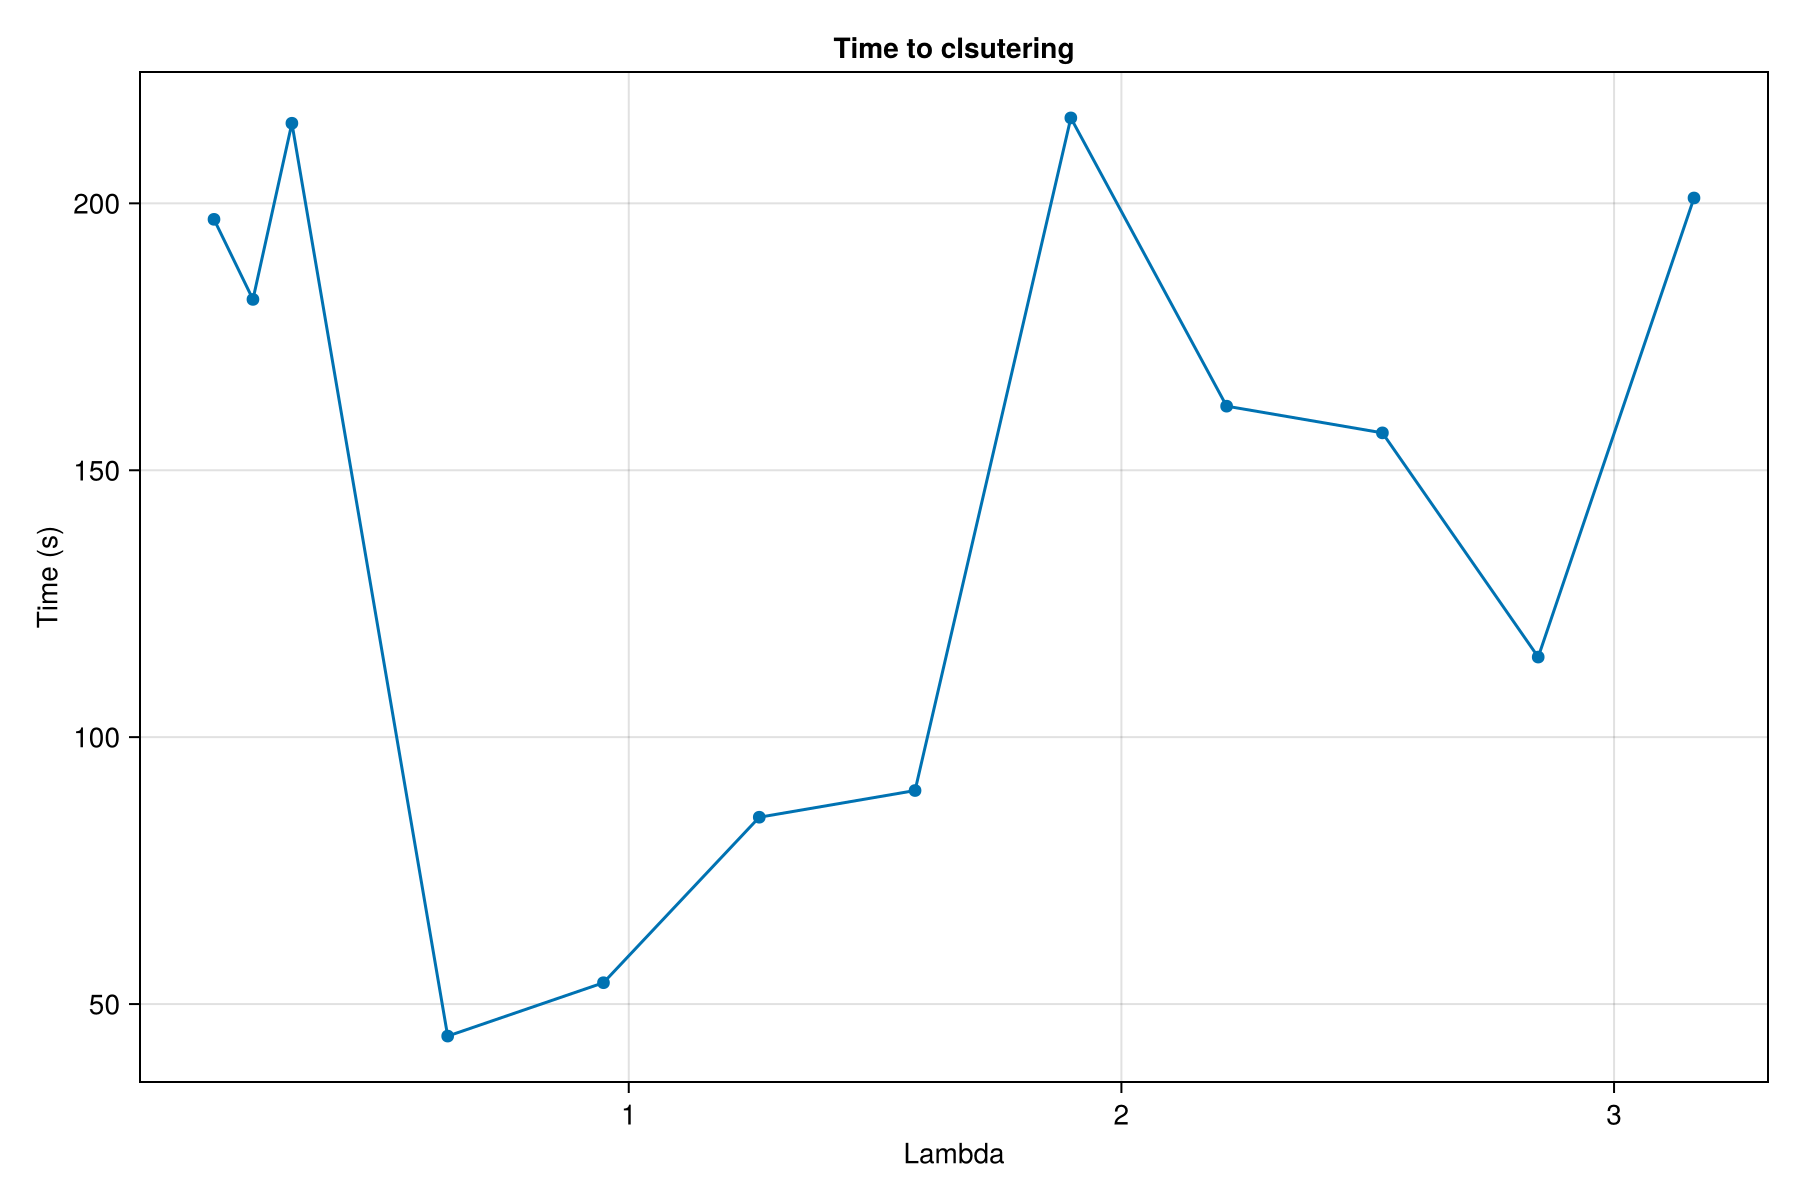

In [ ]:
fig = Figure(size=(900, 600))
ax = CairoMakie.Axis(fig[1,1], title = "Time to clsutering", xlabel = "Lambda", ylabel = "Time (s)")
real_lambdas = [ 0.158113883, 0.2371708245, 0.316227766, 0.632455532, 0.9486832981, 1.264911064, 1.58113883, 1.897366596, 2.213594362, 2.529822128, 2.846049894, 3.16227766]

scatterlines!(ax, real_lambdas, vec_times .* 0.01)
fig

In [40]:
save("Plots/Fixed_source_model/Next/Clustering_time_4.pdf", fig)

CairoMakie.Screen{PDF}


In [75]:

# ---------------------------------------------------------
# Cluster detection (your original logic)
# ---------------------------------------------------------
function compute_cluster_sizes(z; threshold=nothing)

    if threshold === nothing
        threshold = mean(z) + 0.5 * std(z)
    end

    binary = z .> threshold
    labels = label_components(binary)

    n = maximum(labels)

    areas = Float64[]

    for i in 1:n
        a = count(labels .== i)
        if a > 5
            push!(areas, a)
        end
    end

    return [2 * sqrt(a / π) for a in areas]
end


# ---------------------------------------------------------
# Characteristic cluster size
# (you can switch mean ↔ max)
# ---------------------------------------------------------
characteristic_size(z) = begin
    d = compute_cluster_sizes(z)
    isempty(d) && return 0.0
    return mean(d)
end


# ---------------------------------------------------------
# Simple moving average (smoothing)
# ---------------------------------------------------------
function moving_average(x, w)
    y = similar(x)

    n = length(x)

    for i in 1:n
        a = max(1, i - w)
        b = min(n, i + w)
        y[i] = mean(x[a:b])
    end

    return y
end


# ---------------------------------------------------------
# Main function: slope-based clustering time
# ---------------------------------------------------------
function clustering_time_slope(filename;
                                timesteps = 0:100:25000,
                                smooth_window = 5,
                                slope_factor = 0.005)

    times = Int[]
    sizes = Float64[]

    # -----------------------------------------------------
    # Load time series
    # -----------------------------------------------------
    jldopen(filename, "r") do file

        for t in timesteps
            key = @sprintf("step_%06d", t)

            if haskey(file, key)

                g = file[key]
                z = reshape(g["mm_grid"], (200, 200))

                push!(times, t)
                push!(sizes, characteristic_size(z))
            end
        end
    end

    # -----------------------------------------------------
    # Smooth signal (VERY important)
    # -----------------------------------------------------
    smooth_sizes = moving_average(sizes, smooth_window)

    # -----------------------------------------------------
    # Compute time derivative
    # -----------------------------------------------------
    dS = diff(smooth_sizes)

    # map derivative times
    dtimes = times[2:end]

    # -----------------------------------------------------
    # Threshold for "slow growth"
    # -----------------------------------------------------
    threshold = slope_factor * maximum(abs.(dS))

    # -----------------------------------------------------
    # Find first time where growth slows down
    # -----------------------------------------------------
    t_cluster = nothing

    for i in eachindex(dS)
        if abs(dS[i]) < threshold
            t_cluster = dtimes[i]
            break
        end
    end

    return t_cluster, times, sizes, smooth_sizes, dS
end

clustering_time_slope (generic function with 1 method)

In [76]:
vec_times = []
ns = ["05", 0.75, 1.0, 2.0, "3", 4.0, 5.0, 6.0, 7.0, "8", 9.0, 10.0]

for (idx, n) in enumerate(ns)
    filename = "col_PBC_n$(n)_ve10_v10.jld2"

    
    t_cluster, times, sizes, smooth_sizes, dS =
    clustering_time_slope(filename)
    push!(vec_times, t_cluster)
    println("Clustering time ≈ $t_cluster")
end


Clustering time ≈ 5700
Clustering time ≈ 3300
Clustering time ≈ 500
Clustering time ≈ 8800
Clustering time ≈ 3000
Clustering time ≈ 8200
Clustering time ≈ 5200
Clustering time ≈ 13400
Clustering time ≈ 5100
Clustering time ≈ 2300
Clustering time ≈ 6400
Clustering time ≈ 3400


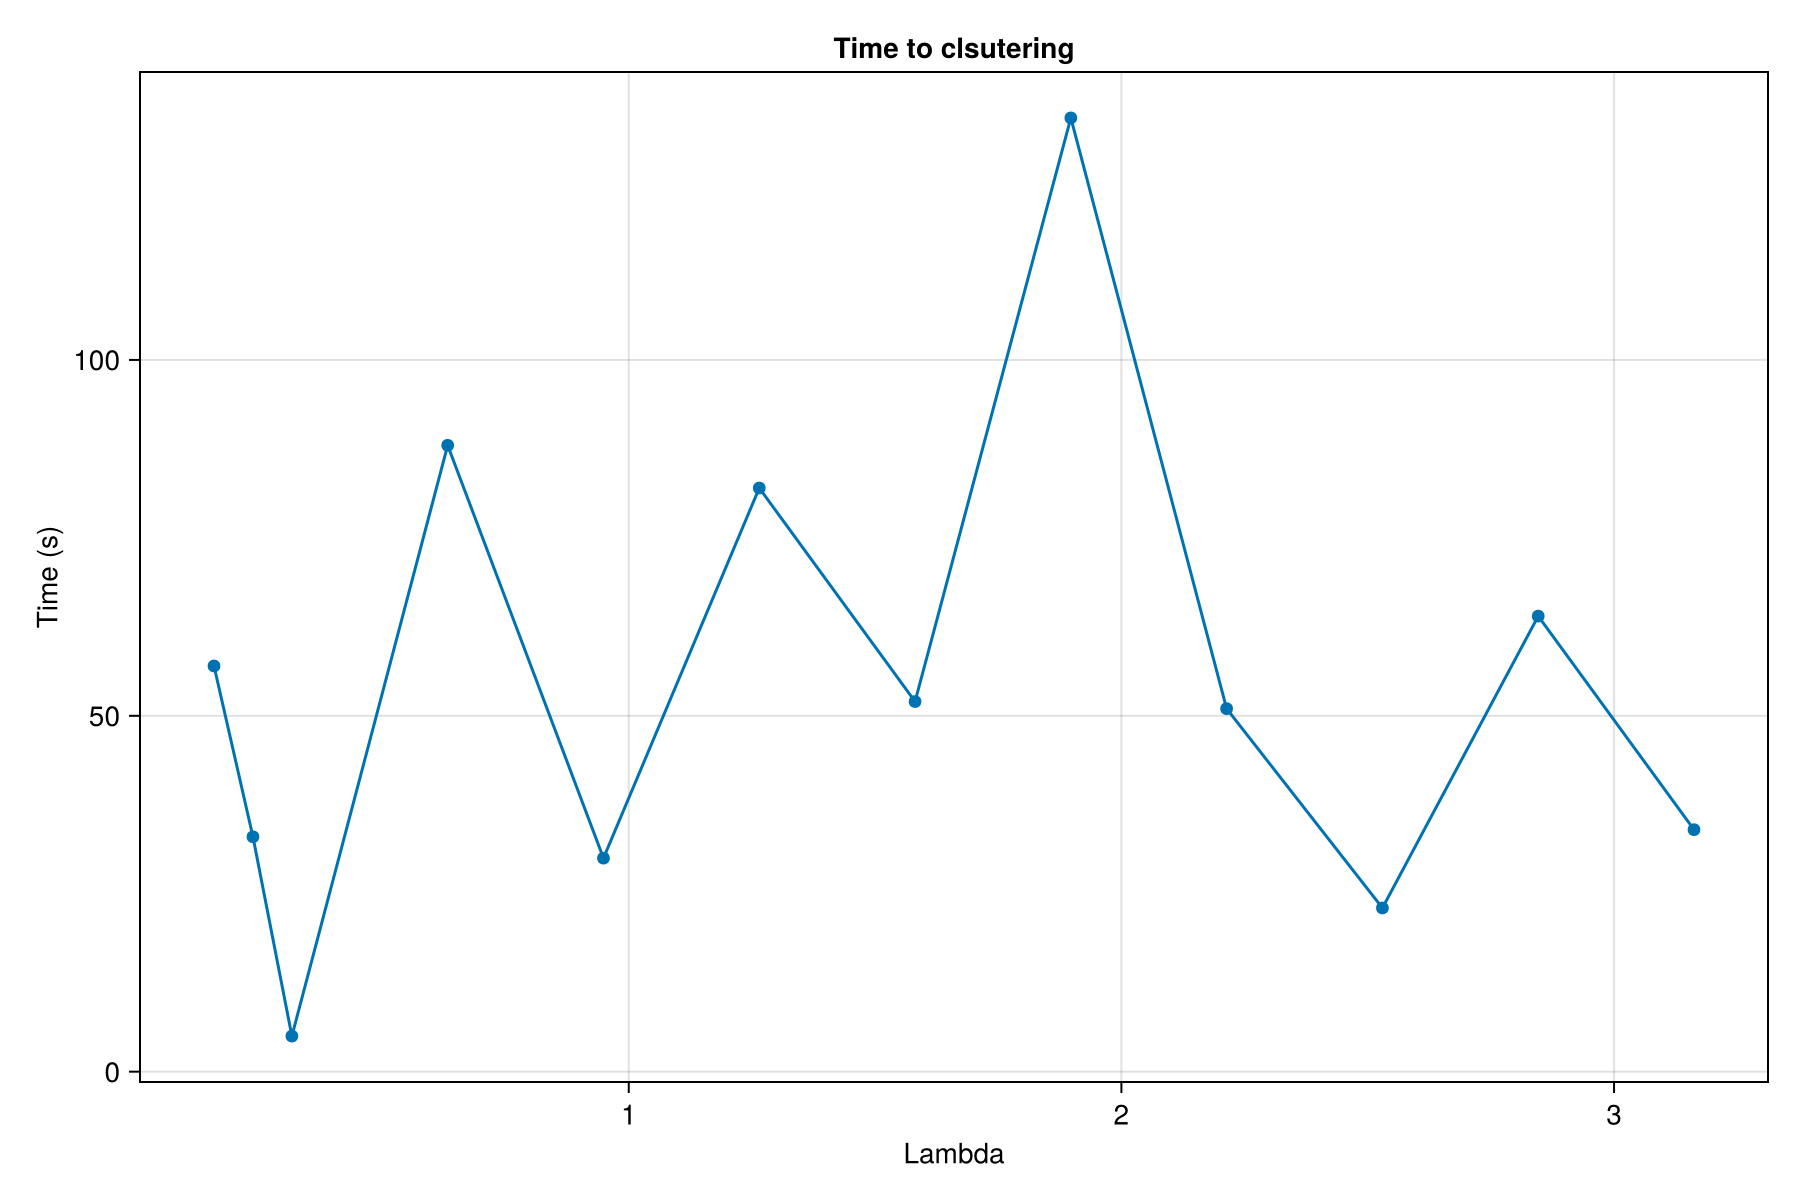

In [77]:
fig = Figure(size=(900, 600))
ax = CairoMakie.Axis(fig[1,1], title = "Time to clsutering", xlabel = "Lambda", ylabel = "Time (s)")
real_lambdas = [ 0.158113883, 0.2371708245, 0.316227766, 0.632455532, 0.9486832981, 1.264911064, 1.58113883, 1.897366596, 2.213594362, 2.529822128, 2.846049894, 3.16227766]

scatterlines!(ax, real_lambdas, vec_times .* 0.01)
fig

## Mask comparison

In [45]:
function clustering_time_pixel_slope_normalized(filename;
                                                 timesteps = 0:200:25000,
                                                 smooth_window = 3,
                                                 slope_factor = 0.05)

    times = Int[]
    sims  = Float64[]

    jldopen(filename, "r") do file

        z_final = load_field(file, maximum(timesteps))
        thr = mean(z_final) + 0.5 * std(z_final)

        b_final = z_final .> thr

        for t in timesteps

            key = @sprintf("step_%06d", t)

            if haskey(file, key)

                z = load_field(file, t)
                b = z .> thr

                push!(times, t)
                push!(sims, mean(b .== b_final))
            end
        end
    end

    # -------------------------------------------------
    # IMPORTANT: normalize similarity
    # -------------------------------------------------
    s0 = sims[1]
    sT = sims[end]

    norm_sims = [(s - s0) / (sT - s0 + 1e-12) for s in sims]

    # -------------------------------------------------
    # smooth
    # -------------------------------------------------
    smooth_sims = moving_average(norm_sims, smooth_window)

    # -------------------------------------------------
    # slope
    # -------------------------------------------------
    dS = diff(smooth_sims)
    dtimes = times[2:end]

    # threshold on slope
    threshold = slope_factor * maximum(abs.(dS))

    # -------------------------------------------------
    # detect slowdown (correct now)
    # -------------------------------------------------
    t_cluster = nothing

    for i in eachindex(dS)
        if abs(dS[i]) < threshold
            t_cluster = dtimes[i]
            break
        end
    end

    return t_cluster, times, norm_sims, smooth_sims, dS
end

clustering_time_pixel_slope_normalized (generic function with 1 method)

In [54]:
vec_times = []
ns = [0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

for (idx, n) in enumerate(ns)
    filename = "cluster_n$(n).jld2"
    t_cluster, times, sims, dS =
    clustering_time_corr(filename)
    push!(vec_times, t_cluster)
    println("Clustering time ≈ $t_cluster")
end


Clustering time ≈ 1200
Clustering time ≈ 600
Clustering time ≈ 400
Clustering time ≈ 400
Clustering time ≈ 800
Clustering time ≈ 400
Clustering time ≈ 400
Clustering time ≈ 400
Clustering time ≈ 400
Clustering time ≈ 400
Clustering time ≈ 400
Clustering time ≈ 600


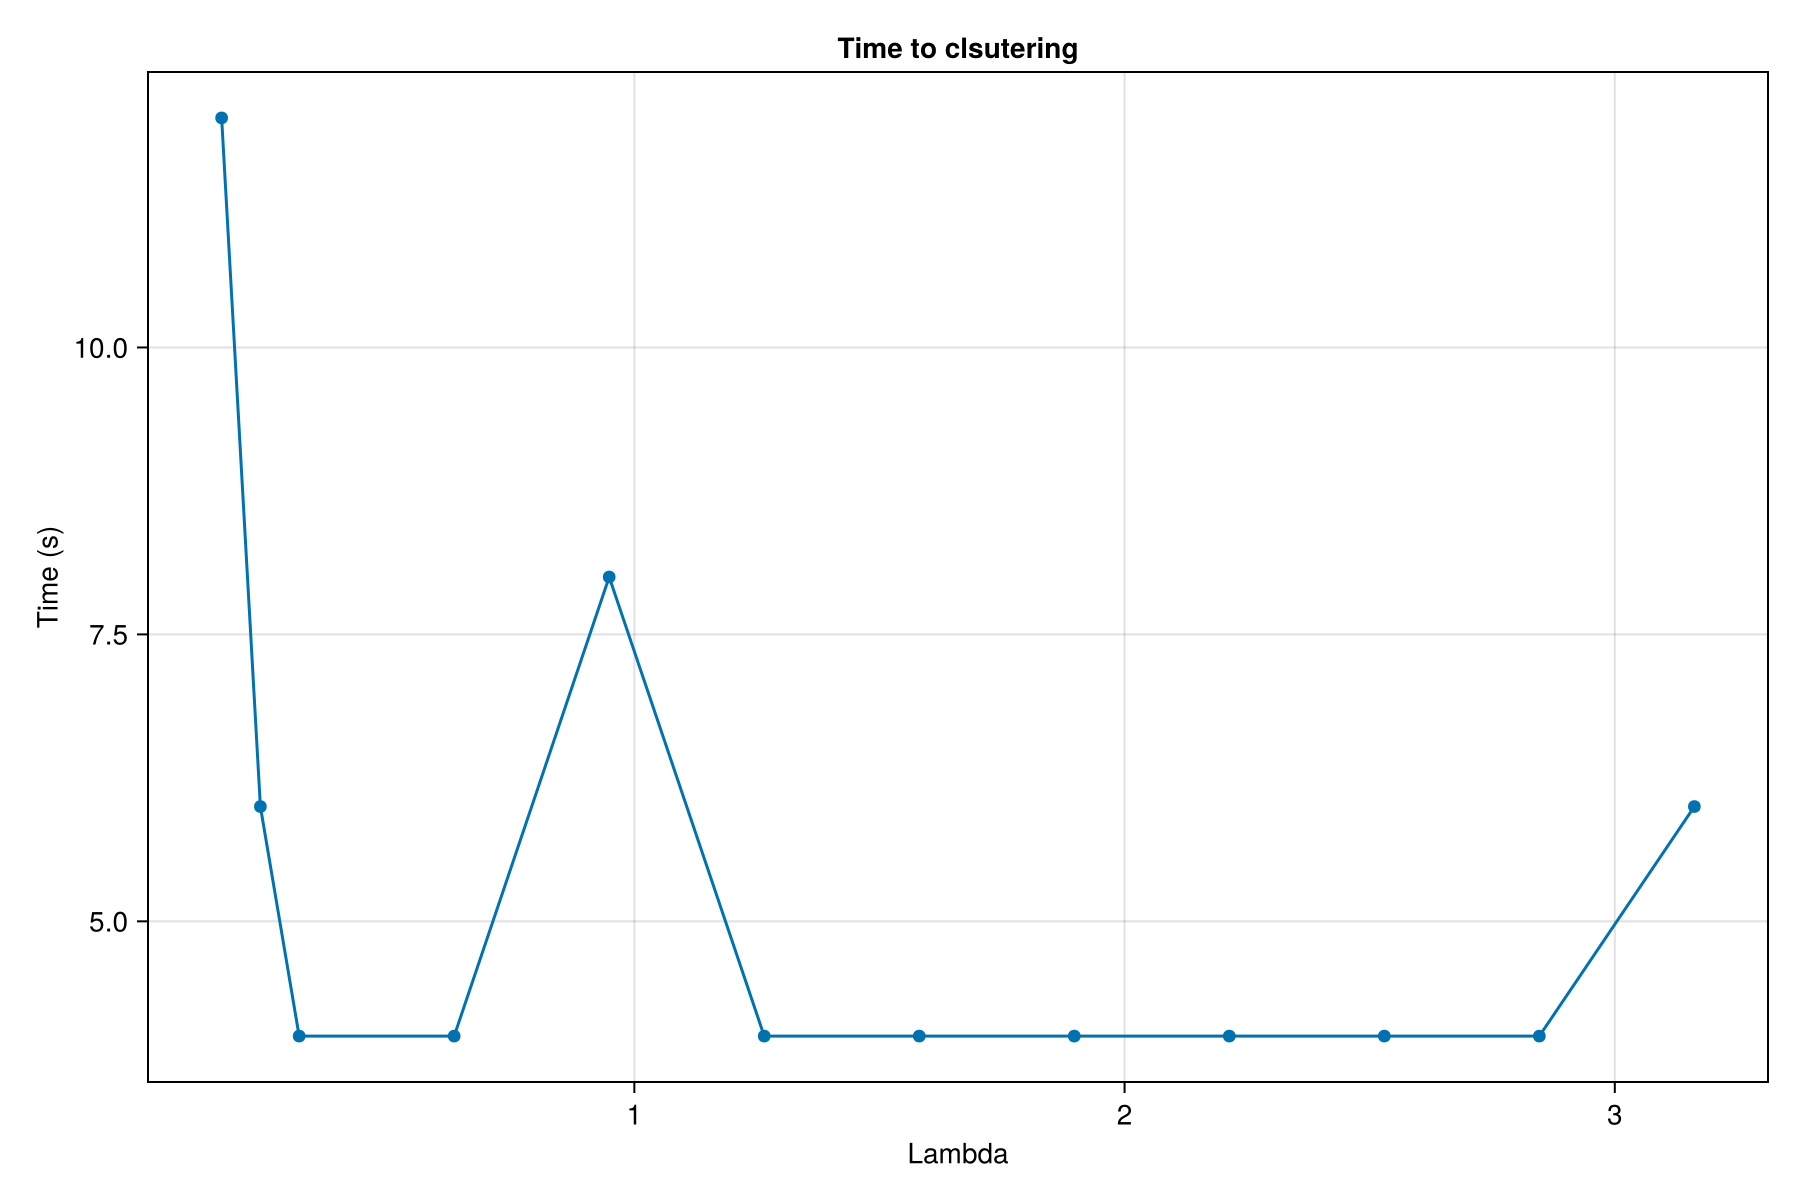

In [55]:
fig = Figure(size=(900, 600))
ax = CairoMakie.Axis(fig[1,1], title = "Time to clsutering", xlabel = "Lambda", ylabel = "Time (s)")
real_lambdas = [ 0.158113883, 0.2371708245, 0.316227766, 0.632455532, 0.9486832981, 1.264911064, 1.58113883, 1.897366596, 2.213594362, 2.529822128, 2.846049894, 3.16227766]

scatterlines!(ax, real_lambdas, vec_times .* 0.01)
fig

In [ ]:
using JLD2
using Statistics
using Printf
using Images, ImageSegmentation

# ---------------------------------------------------------
# Load field
# ---------------------------------------------------------
function load_field(file, step)
    key = @sprintf("step_%06d", step)
    g = file[key]
    return reshape(g["mm_grid"], (200, 200))
end


# ---------------------------------------------------------
# Binary mask
# ---------------------------------------------------------
function binary_field(z)
    thr = mean(z) + 0.5 * std(z)
    return z .> thr
end


# ---------------------------------------------------------
# Pixel similarity with final state
# ---------------------------------------------------------
pixel_similarity(a, b) = mean(a .== b)


# ---------------------------------------------------------
# Moving average smoothing (important for slope stability)
# ---------------------------------------------------------
function moving_average(x, w)
    n = length(x)
    y = similar(x)

    for i in 1:n
        a = max(1, i - w)
        b = min(n, i + w)
        y[i] = mean(x[a:b])
    end

    return y
end


# ---------------------------------------------------------
# Main function: slope-based clustering time
# ---------------------------------------------------------
function clustering_time_pixel_slope(filename;
                                     timesteps = 0:100:25000,
                                     smooth_window = 10,
                                     slope_factor = 0.02)

    times = Int[]
    sims  = Float64[]

    jldopen(filename, "r") do file

        # -------------------------------------------------
        # reference final state
        # -------------------------------------------------
        z_final = load_field(file, maximum(timesteps))
        b_final = binary_field(z_final)

        # -------------------------------------------------
        # compute similarity over time
        # -------------------------------------------------
        for t in timesteps

            key = @sprintf("step_%06d", t)

            if haskey(file, key)

                z = load_field(file, t)
                b = binary_field(z)

                push!(times, t)
                push!(sims, pixel_similarity(b, b_final))
            end
        end
    end

    # ---------------------------------------------------------
    # smooth similarity curve
    # ---------------------------------------------------------
    smooth_sims = moving_average(sims, smooth_window)

    # ---------------------------------------------------------
    # compute slope dS/dt
    # ---------------------------------------------------------
    dS = diff(smooth_sims)
    dtimes = times[2:end]

    # ---------------------------------------------------------
    # define threshold = small fraction of max growth rate
    # ---------------------------------------------------------
    threshold = slope_factor * maximum(abs.(dS))

    # ---------------------------------------------------------
    # find first time slope becomes small
    # ---------------------------------------------------------
    t_cluster = nothing

    for i in eachindex(dS)

        if abs(dS[i]) < threshold
            t_cluster = dtimes[i]
            break
        end
    end

    return t_cluster, times, sims, smooth_sims, dS
end

clustering_time_pixel_slope (generic function with 1 method)

In [56]:
function clustering_time_corr(filename;
                               timesteps = 0:100:25000)

    times = Int[]
    sims  = Float64[]

    jldopen(filename, "r") do file

        z_final = load_field(file, maximum(timesteps))
        zf = z_final .- mean(z_final)

        for t in timesteps

            key = @sprintf("step_%06d", t)

            if haskey(file, key)

                z = load_field(file, t)
                z = z .- mean(z)

                # cosine similarity (robust choice)
                s = sum(z .* zf) / (norm(z) * norm(zf) + 1e-12)

                push!(times, t)
                push!(sims, s)
            end
        end
    end

    # slope method
    dS = diff(sims)
    dt = times[2:end]

    t_cluster = dt[argmax(dS)]  # peak growth = true clustering time

    return t_cluster, times, sims, dS
end

clustering_time_corr (generic function with 1 method)

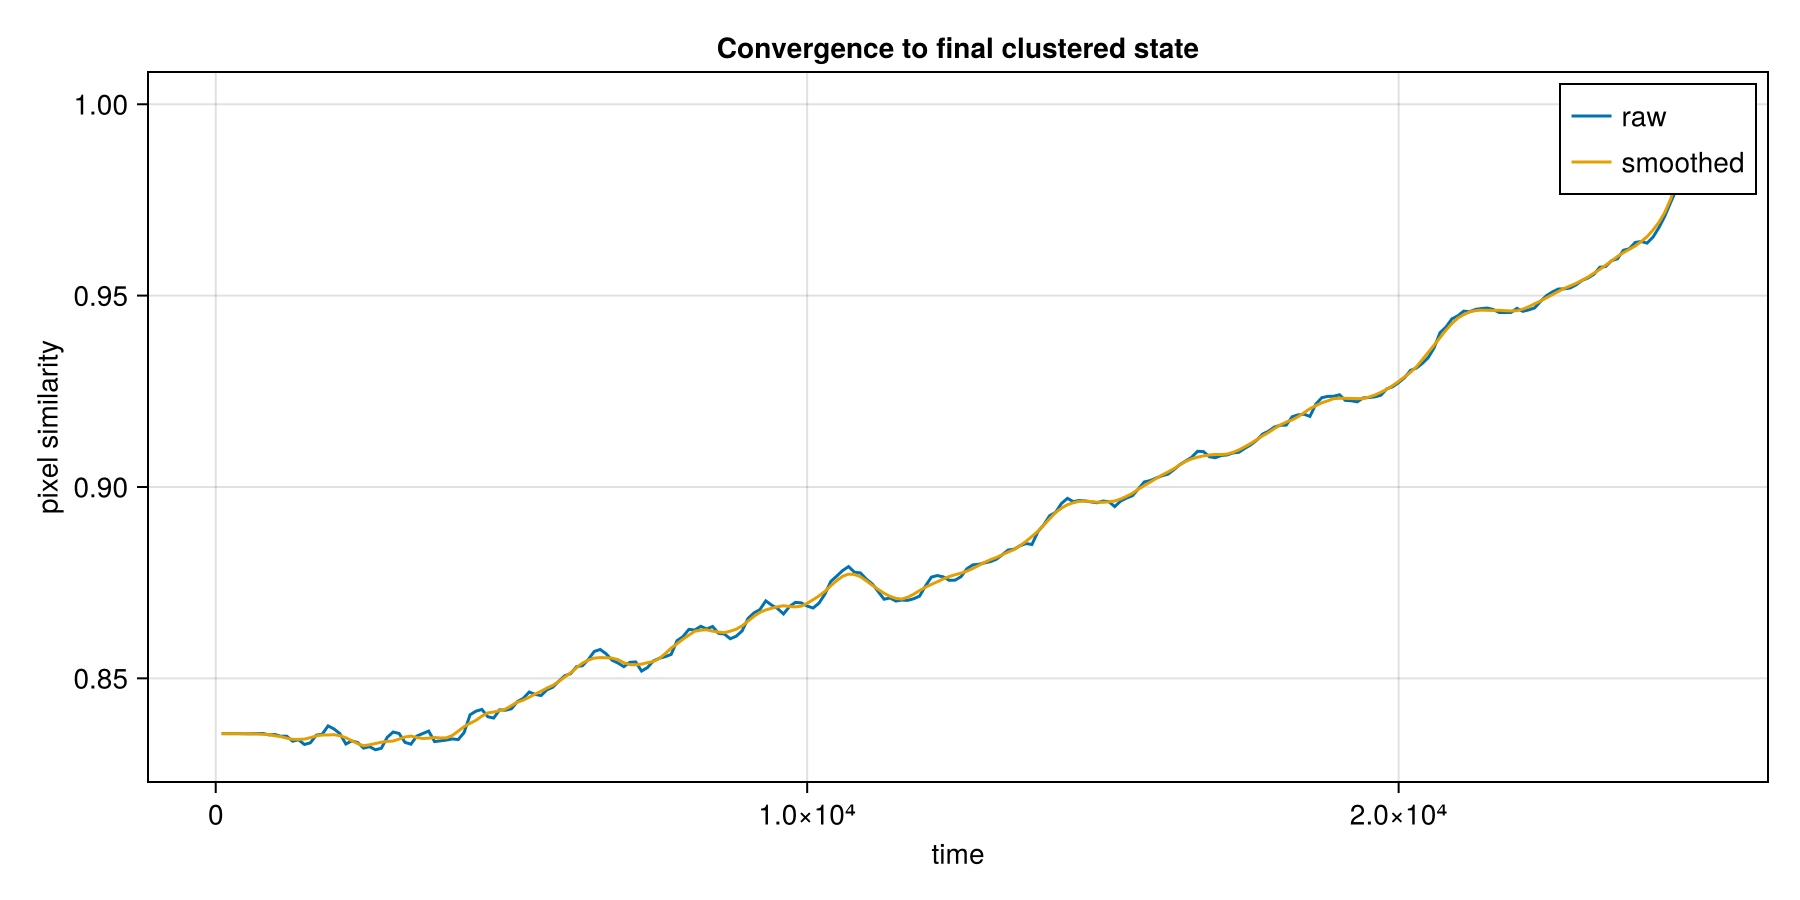

In [77]:
using CairoMakie

filename = "cluster_n8.0.jld2"

t_cluster, times, sims, smooth_sims, dS =
    clustering_time_pixel_slope_fixed(filename)

fig = Figure(size = (900, 450))

ax = Axis(fig[1, 1],
    xlabel = "time",
    ylabel = "pixel similarity",
    title = "Convergence to final clustered state"
)

# raw similarity
lines!(ax, times, sims, label = "raw")

# smoothed similarity
lines!(ax, times, smooth_sims, label = "smoothed")

axislegend(ax)

fig

In [80]:
using JLD2
using Statistics
using Printf
using Images, ImageSegmentation

# ---------------------------------------------------------
# Load field
# ---------------------------------------------------------
function load_field(file, step)
    key = @sprintf("step_%06d", step)
    g = file[key]
    return reshape(g["mm_grid"], (200, 200))
end


# ---------------------------------------------------------
# FIXED threshold from final state ONLY
# ---------------------------------------------------------
function get_threshold(z_final)
    return mean(z_final) + 0.5 * std(z_final)
end


# ---------------------------------------------------------
# Binary mask
# ---------------------------------------------------------
binary(z, thr) = z .> thr


# ---------------------------------------------------------
# Jaccard similarity (robust for morphology)
# ---------------------------------------------------------
function jaccard(a, b)
    inter = sum(a .& b)
    uni   = sum(a .| b)
    return inter / max(uni, 1)
end


# ---------------------------------------------------------
# MAIN FUNCTION: correlation-style clustering time
# ---------------------------------------------------------
function clustering_time_corr_threshold(filename;
                                        timesteps = 0:100:25000,
                                        similarity_threshold = 0.5)

    times = Int[]
    sims  = Float64[]

    jldopen(filename, "r") do file

        # -------------------------------------------------
        # reference FINAL mask
        # -------------------------------------------------
        z_final = load_field(file, maximum(timesteps))
        thr = get_threshold(z_final)

        b_final = binary(z_final, thr)

        # -------------------------------------------------
        # compute similarity curve
        # -------------------------------------------------
        for t in timesteps

            key = @sprintf("step_%06d", t)

            if haskey(file, key)

                z = load_field(file, t)
                b = binary(z, thr)

                s = jaccard(b, b_final)

                push!(times, t)
                push!(sims, s)
            end
        end
    end

    # ---------------------------------------------------------
    # clustering time = first time reaching threshold
    # ---------------------------------------------------------
    t_cluster = nothing

    for i in eachindex(sims)

        if sims[i] ≥ similarity_threshold
            t_cluster = times[i]
            break
        end
    end

    return t_cluster, times, sims
end

clustering_time_corr_threshold (generic function with 1 method)

In [81]:
vec_times = []
ns = [0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

for (idx, n) in enumerate(ns)
    filename = "cluster_n$n.jld2"

    t_cluster, times, sizes = clustering_time_corr_threshold(filename)
    push!(vec_times, t_cluster)
    println("Clustering time ≈ $t_cluster")
end


Clustering time ≈ 12000
Clustering time ≈ 14600
Clustering time ≈ 19100
Clustering time ≈ 6200
Clustering time ≈ 7400
Clustering time ≈ 10600
Clustering time ≈ 7300
Clustering time ≈ 12800
Clustering time ≈ 13400
Clustering time ≈ 14100
Clustering time ≈ 17800
Clustering time ≈ 21000


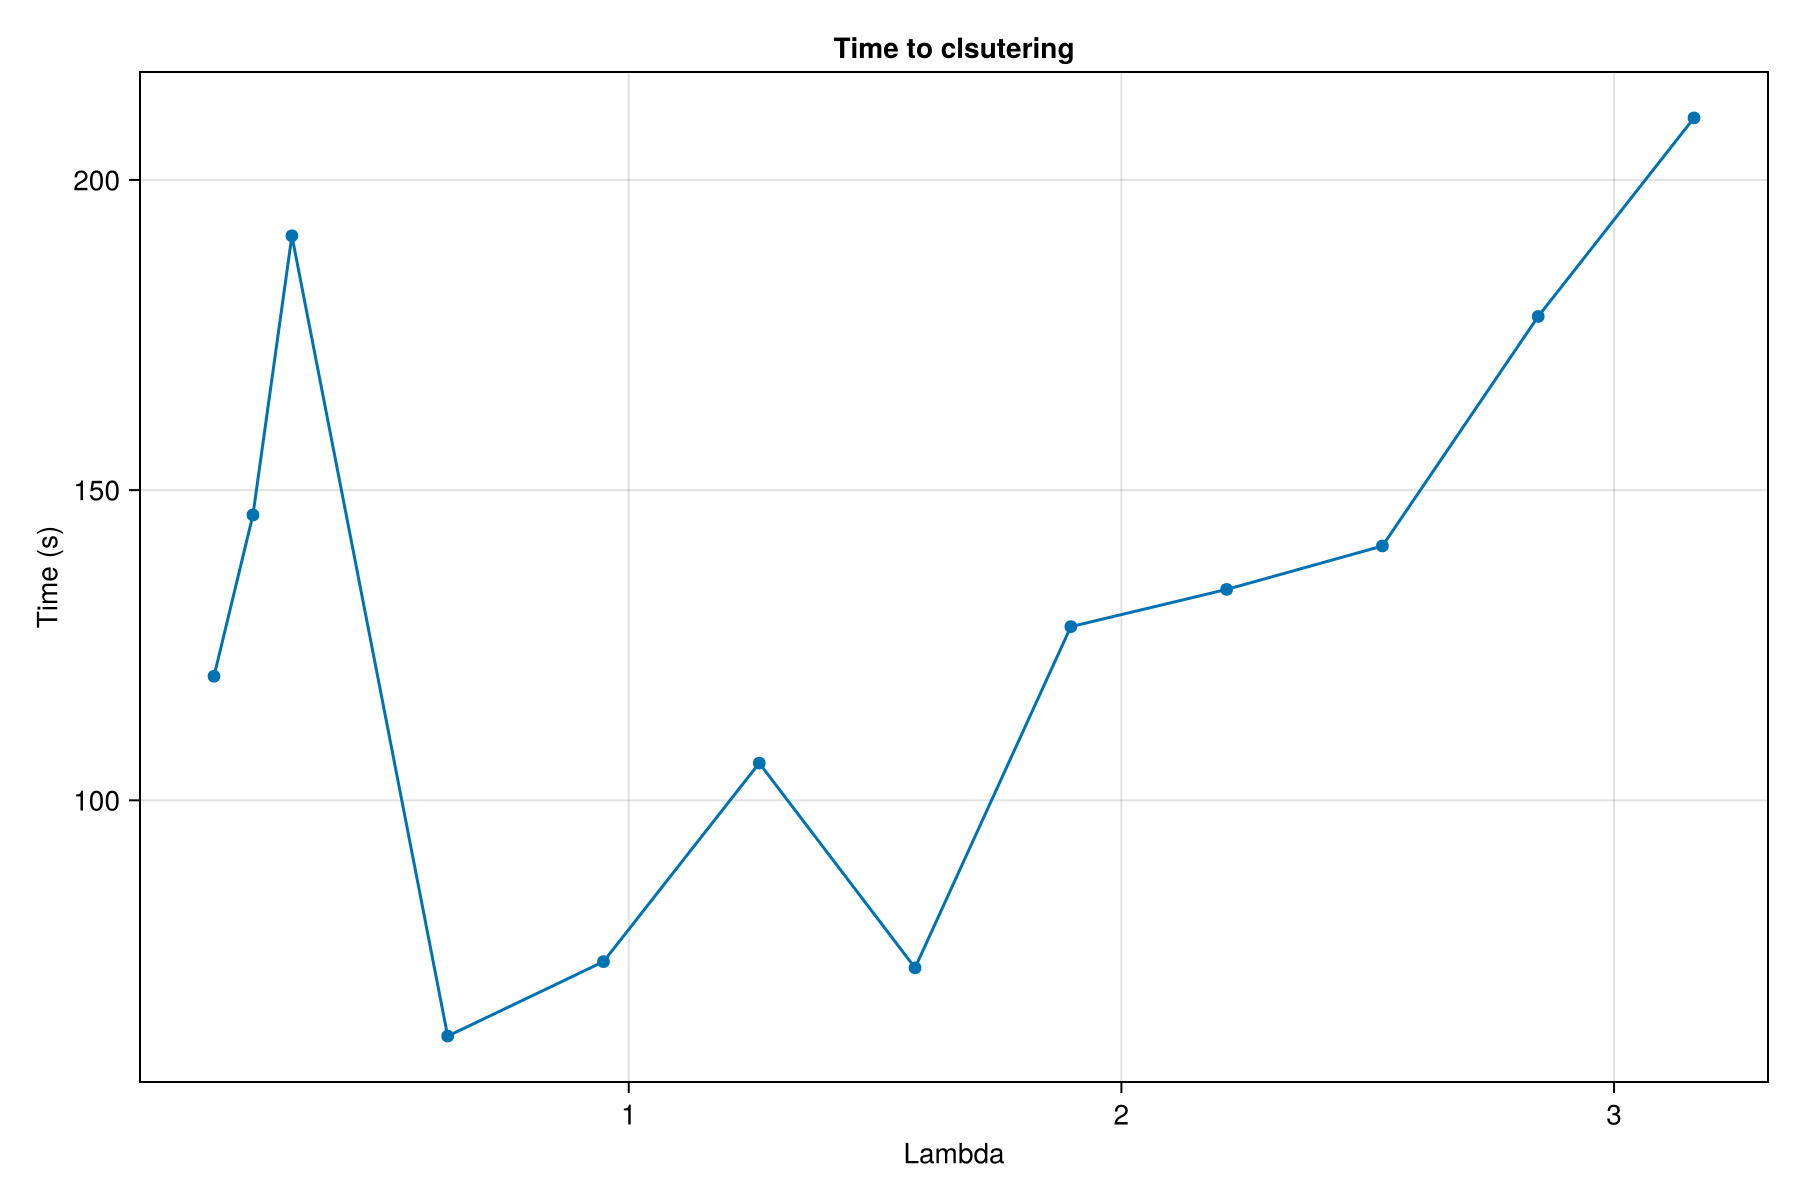

In [82]:
fig = Figure(size=(900, 600))
ax = CairoMakie.Axis(fig[1,1], title = "Time to clsutering", xlabel = "Lambda", ylabel = "Time (s)")
real_lambdas = [ 0.158113883, 0.2371708245, 0.316227766, 0.632455532, 0.9486832981, 1.264911064, 1.58113883, 1.897366596, 2.213594362, 2.529822128, 2.846049894, 3.16227766]

scatterlines!(ax, real_lambdas, vec_times .* 0.01)
fig

In [24]:
using JLD2
using Statistics
using Printf
using Images, ImageSegmentation

# ---------------------------------------------------------
# Load field from file
# ---------------------------------------------------------
function load_field(file, step)
    key = @sprintf("step_%06d", step)
    g = file[key]
    return reshape(g["mm_grid"], (200, 200))
end


# ---------------------------------------------------------
# Fixed threshold (computed from FINAL state once)
# ---------------------------------------------------------
function compute_threshold(z)
    return mean(z) + 0.5 * std(z)
end


# ---------------------------------------------------------
# Binary mask
# ---------------------------------------------------------
binary(z, thr) = z .> thr


# ---------------------------------------------------------
# Jaccard similarity (robust structural overlap)
# ---------------------------------------------------------
function jaccard(a, b)
    inter = sum(a .& b)
    uni   = sum(a .| b)
    return inter / max(uni, 1)
end


# ---------------------------------------------------------
# MAIN FUNCTION
# ---------------------------------------------------------
function clustering_time_jaccard(filename;
                                  timesteps = 0:100:25000,
                                  similarity_threshold = 0.8)

    times = Int[]
    sims  = Float64[]

    t_cluster = nothing

    jldopen(filename, "r") do file

        # -------------------------------------------------
        # reference final state
        # -------------------------------------------------
        z_final = load_field(file, maximum(timesteps))
        thr = compute_threshold(z_final)

        b_final = binary(z_final, thr)

        # -------------------------------------------------
        # compute similarity over time
        # -------------------------------------------------
        for t in timesteps

            key = @sprintf("step_%06d", t)

            if haskey(file, key)

                z = load_field(file, t)
                b = binary(z, thr)

                s = jaccard(b, b_final)

                push!(times, t)
                push!(sims, s)

                # -------------------------------------------------
                # first-passage detection (clustering time)
                # -------------------------------------------------
                if t_cluster === nothing && s ≥ similarity_threshold
                    t_cluster = t
                end
            end
        end
    end

    return t_cluster, times, sims
end

clustering_time_jaccard (generic function with 1 method)

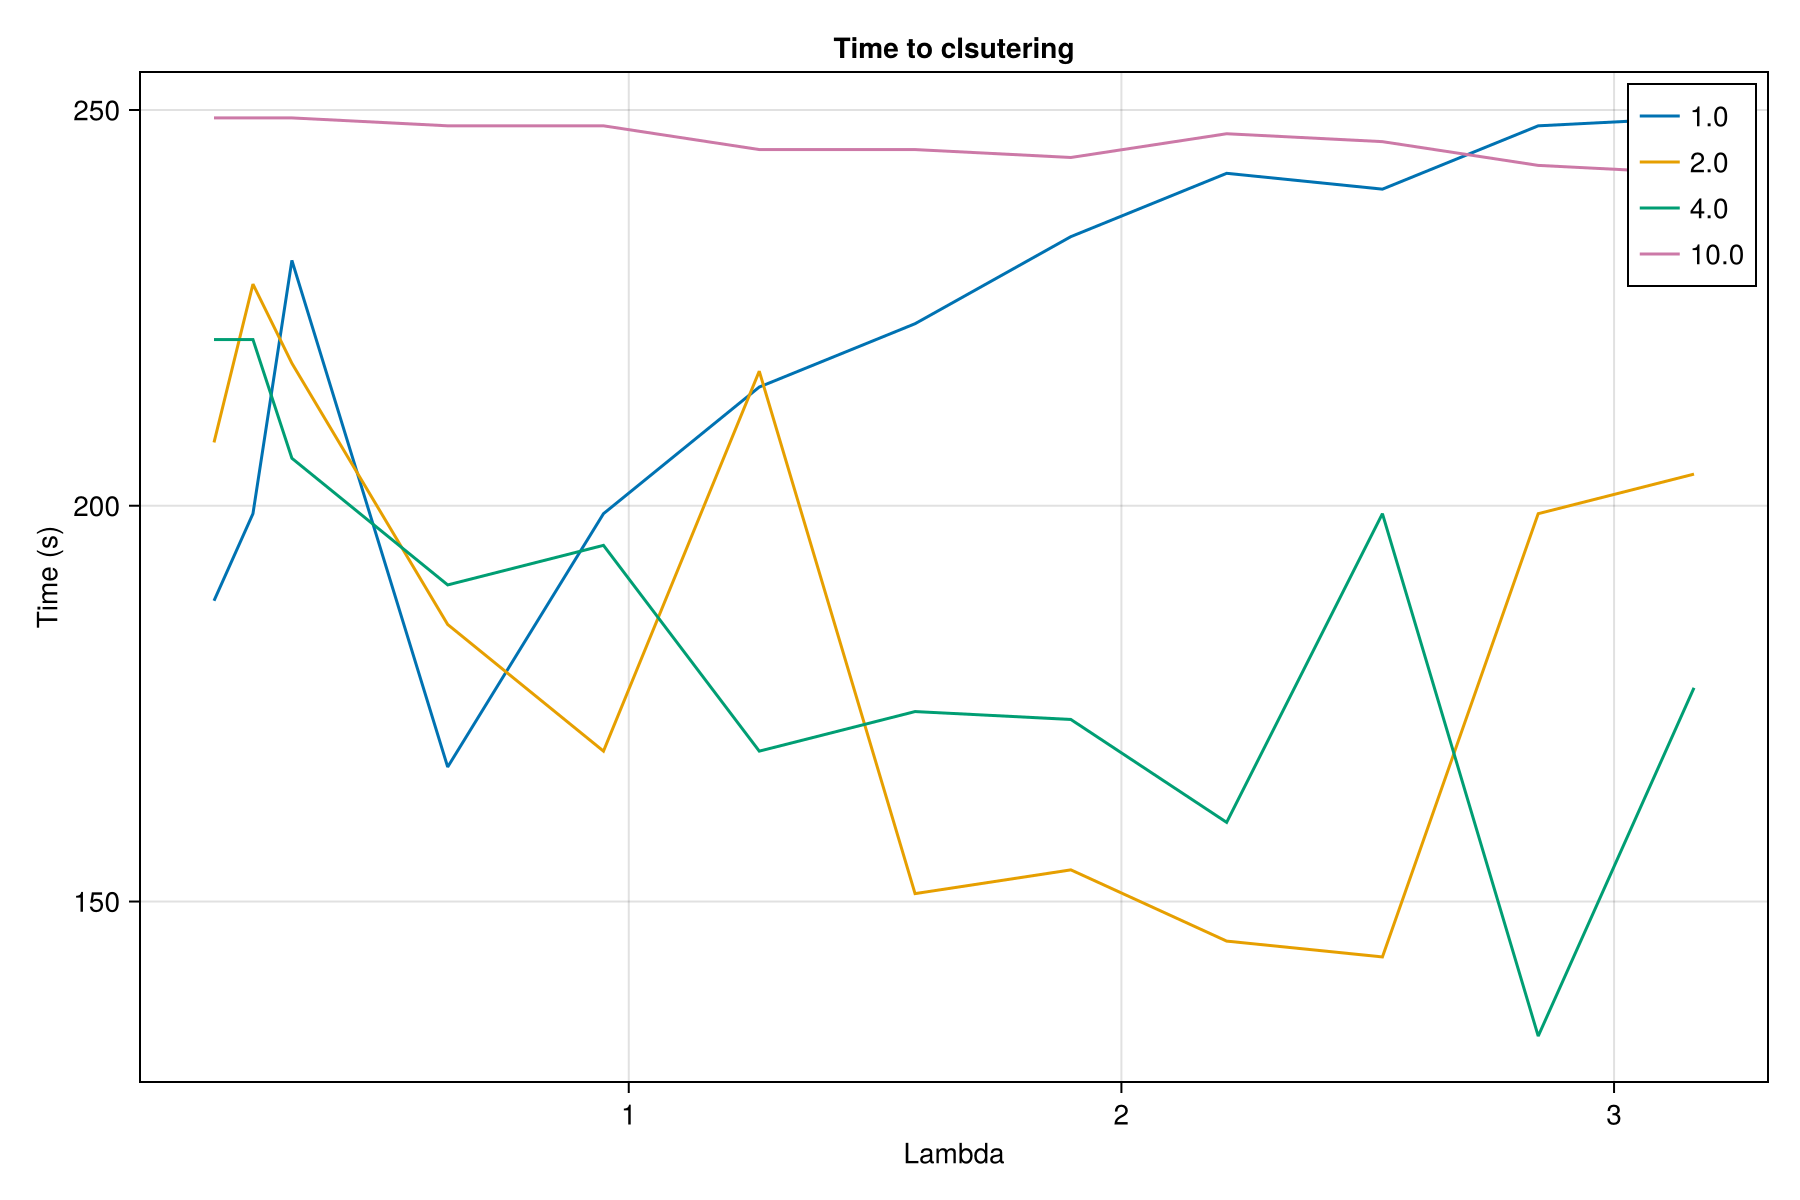

In [25]:

ns = [0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
tms = [1.0, 2.0, 4.0, 10.0]
fig = Figure(size=(900, 600))
ax = CairoMakie.Axis(fig[1,1], title = "Time to clsutering", xlabel = "Lambda", ylabel = "Time (s)")
real_lambdas = [ 0.158113883, 0.2371708245, 0.316227766, 0.632455532, 0.9486832981, 1.264911064, 1.58113883, 1.897366596, 2.213594362, 2.529822128, 2.846049894, 3.16227766]


for (idx_t, tm) in enumerate(tms)
    vec_times = []
    for (idx, n) in enumerate(ns)
        filename = "cluster_tm_$(tm)_n$(n).jld2"

        t_cluster, times, sizes = clustering_time_jaccard(filename)
        push!(vec_times, t_cluster)
        # println("Clustering time ≈ $t_cluster, $n")
    end
    lines!(ax, real_lambdas, vec_times .* 0.01, label = "$tm")
end
axislegend(ax)
fig

In [26]:
save("Plots/Fixed_source_model/Next/time_cluster_tms_threshold_08.pdf", fig)

CairoMakie.Screen{PDF}
